# Validierung Gesamt â€“ ems_realistisch_2023/2024/2025.xlsx

**Ziel:** Explorative Validierung des kompletten realistischen Mockdaten-Bestands Ã¼ber
drei Jahre (2023â€“2025): Verteilungen, zeitliche Muster, Jahres- und Saisonvergleiche,
PlausibilitÃ¤ts-Constraints. Diagramme werden unter `output/validierung_gesamt_XX.png`
(bestehende Analysen) bzw. `output/validierung_vergleich_XX.png` (neue Vergleiche) gespeichert.

**Datenquellen:** `input/ems_realistisch_2023.xlsx`, `input/ems_realistisch_2024.xlsx`,
`input/ems_realistisch_2025.xlsx` (je Sheet 0, kein benanntes Sheet)
Spalten: `date, time, PLZ, incident_type_(id), gender, age, location_type_(id)`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import PLZ_TO_GEBIET, GEBIET_NAMES, map_plz_to_gebiet

INPUT_FILES = [
    ROOT / 'input' / 'ems_realistisch_2023.xlsx',
    ROOT / 'input' / 'ems_realistisch_2024.xlsx',
    ROOT / 'input' / 'ems_realistisch_2025.xlsx',
]
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

type_names = {1: 'Herz-Kreislauf', 2: 'Atemnot', 3: 'Bewusstlosigkeit', 4: 'Sturz',
              5: 'Verkehrsunfall', 6: 'Arbeitsunfall', 7: 'Psychisch', 8: 'Intox',
              9: 'Krankentransport', 10: 'Schwangerschaft', 11: 'Sonstiges'}
loc_names = {1: 'Zuhause', 2: 'Ã–ffentlich', 3: 'Arbeit', 4: 'Verkehr'}

# Kurznamen der Gebiete fuer kompakte Achsenbeschriftungen (V6)
GEBIET_KURZ = {
    1: 'Linz', 2: 'Wels', 3: 'Rohrbach', 4: 'Freistadt', 5: 'Perg',
    6: 'Linz-Land', 7: 'Steyr', 8: 'Kirchdorf', 9: 'VÃ¶cklabruck',
    10: 'Salzkammergut', 11: 'Ried', 12: 'Braunau', 13: 'SchÃ¤rding',
    14: 'Grieskirchen', 15: 'Urfahr',
}

season_map = {12: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3}
season_names = {0: 'Winter', 1: 'FrÃ¼hling', 2: 'Sommer', 3: 'Herbst'}
SEASON_ORDER = ['Winter', 'FrÃ¼hling', 'Sommer', 'Herbst']

print('Imports OK')

Imports OK


## Daten laden & aufbereiten

In [2]:
frames = []
for path in INPUT_FILES:
    part = pd.read_excel(path, sheet_name=0)
    part['year'] = pd.to_datetime(part['date']).dt.year
    frames.append(part)
    print(f'Geladen: {path.name} -> Shape {part.shape}')

df = pd.concat(frames, ignore_index=True)
print(f'\nGesamt-Shape: {df.shape}')
print(f'\nFehlende Werte:')
print(df.isnull().sum())

TCOL, LCOL = 'incident_type_(id)', 'location_type_(id)'

# Lesbare Labels
df['type_name'] = df[TCOL].map(type_names)
df['loc_name'] = df[LCOL].map(loc_names)

# Zeitfeatures
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek  # 0=Mo ... 6=So
df['month'] = df['datetime'].dt.month
df['date'] = df['datetime'].dt.normalize()
df['year'] = df['year'].astype(int)

# Saison
df['season'] = df['month'].map(season_map)
df['season_name'] = df['season'].map(season_names)

# Gebiet-Mapping
df['gebiet_id'] = df['PLZ'].apply(map_plz_to_gebiet)
df['gebiet_name'] = df['gebiet_id'].map(GEBIET_NAMES)
n_unmapped = (df['gebiet_id'] == -1).sum()
print(f'\nZeitraum: {df["date"].min().date()} bis {df["date"].max().date()}')
print(f'Nicht gemappte PLZ: {n_unmapped}')
print(f'\nEinsÃ¤tze pro Jahr:')
print(df['year'].value_counts().sort_index())

df.head(3)

Geladen: ems_realistisch_2023.xlsx -> Shape (212453, 8)
Geladen: ems_realistisch_2024.xlsx -> Shape (260025, 8)
Geladen: ems_realistisch_2025.xlsx -> Shape (259909, 8)

Gesamt-Shape: (732387, 8)

Fehlende Werte:
date                  0
time                  0
PLZ                   0
incident_type_(id)    0
gender                0
age                   0
location_type_(id)    0
year                  0
dtype: int64

Zeitraum: 2023-01-01 bis 2025-12-31
Nicht gemappte PLZ: 0

EinsÃ¤tze pro Jahr:
year
2023    212453
2024    260025
2025    259909
Name: count, dtype: int64


,date,time,PLZ,incident_type_(id),gender,age,location_type_(id),year,type_name,loc_name,datetime,hour,weekday,month,season,season_name,gebiet_id,gebiet_name
0,2023-01-01,18:31,4221,9,w,39,1,2023,Krankentransport,Zuhause,2023-01-01 18:31:00,18,6,1,0,Winter,1,Linz
1,2023-01-01,11:57,4020,2,w,40,1,2023,Atemnot,Zuhause,2023-01-01 11:57:00,11,6,1,0,Winter,1,Linz
2,2023-01-01,15:17,4221,9,w,78,1,2023,Krankentransport,Zuhause,2023-01-01 15:17:00,15,6,1,0,Winter,1,Linz


## 1 â€“ Einsatztyp-Verteilung

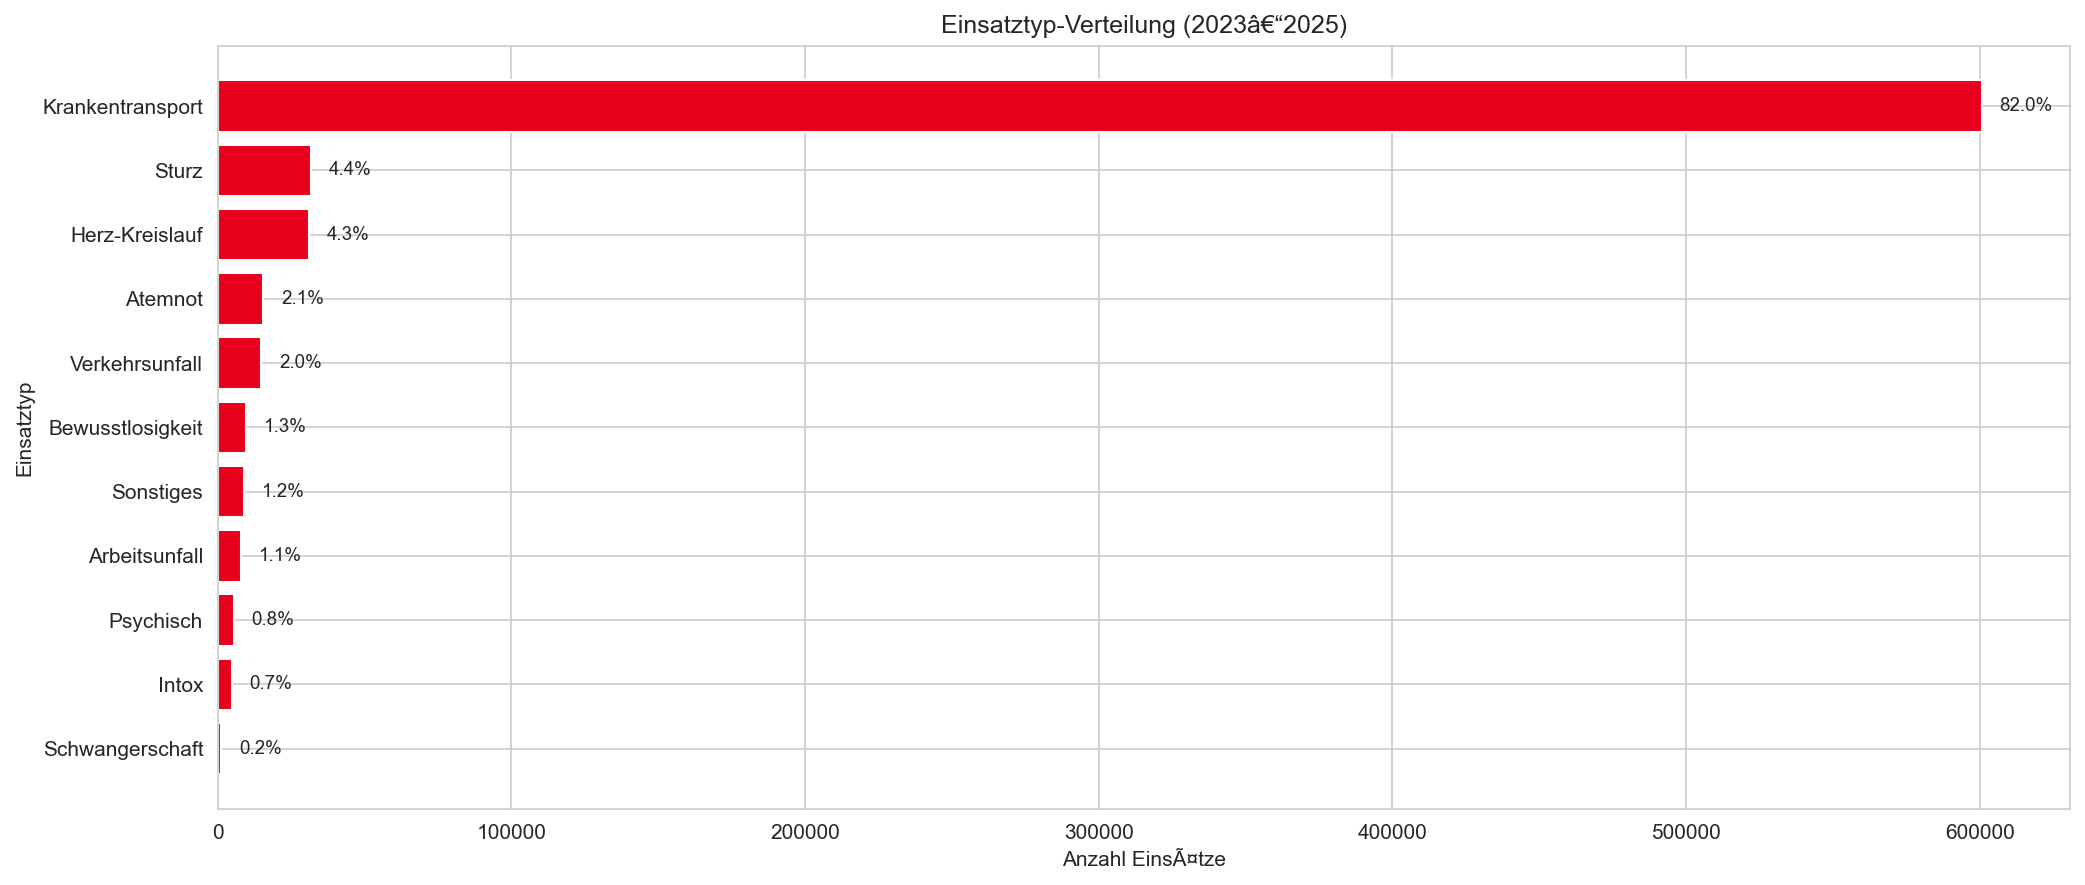

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_01.png


In [3]:
type_counts = df['type_name'].value_counts().sort_values(ascending=True)
type_pct = type_counts / type_counts.sum() * 100

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
bars = ax.barh(type_counts.index, type_counts.values, color='#E8001C')
for bar, pct in zip(bars, type_pct.values):
    ax.text(bar.get_width() + type_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_title('Einsatztyp-Verteilung (2023â€“2025)')
ax.set_xlabel('Anzahl EinsÃ¤tze')
ax.set_ylabel('Einsatztyp')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_01.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 2 â€“ Tageszeit-Verteilung: Krankentransport vs. NotfÃ¤lle

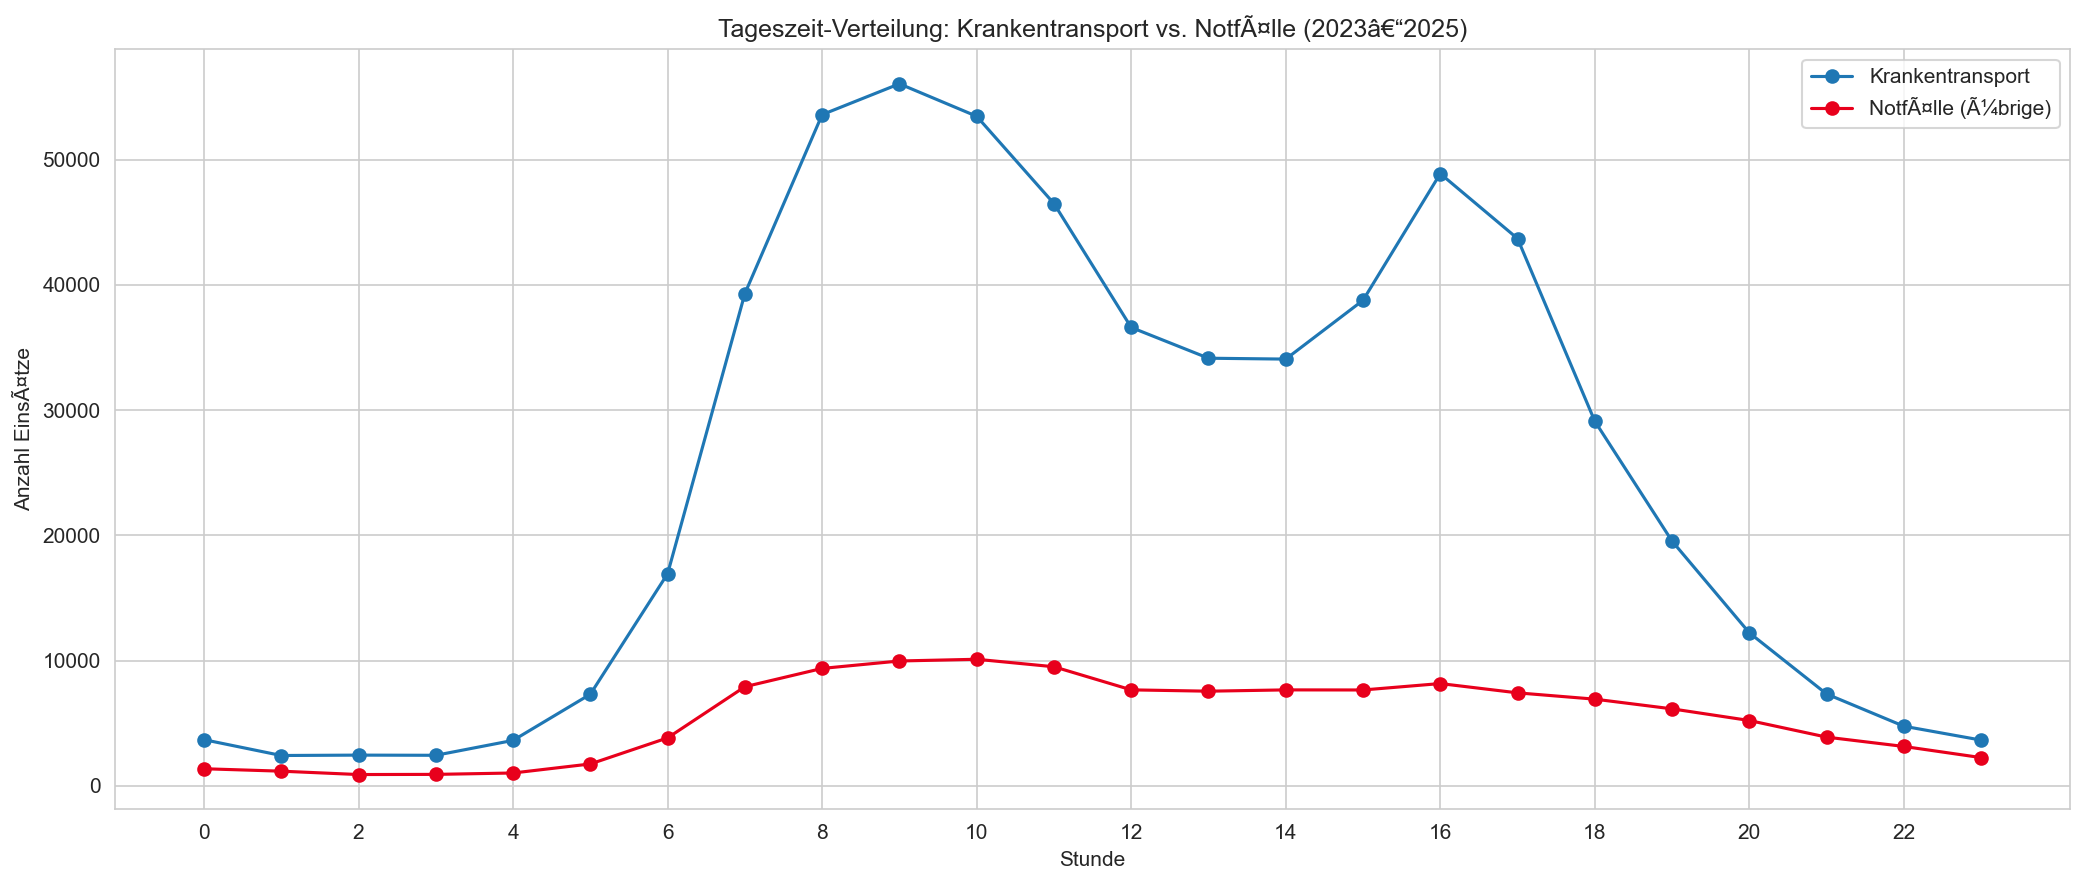

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_02.png


In [4]:
is_kt = df['type_name'] == 'Krankentransport'

hourly_kt = df[is_kt].groupby('hour').size().reindex(range(24), fill_value=0)
hourly_notfall = df[~is_kt].groupby('hour').size().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.plot(hourly_kt.index, hourly_kt.values, marker='o', label='Krankentransport', color='#1f77b4')
ax.plot(hourly_notfall.index, hourly_notfall.values, marker='o', label='NotfÃ¤lle (Ã¼brige)', color='#E8001C')

ax.set_title('Tageszeit-Verteilung: Krankentransport vs. NotfÃ¤lle (2023â€“2025)')
ax.set_xlabel('Stunde')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_02.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 3 â€“ Wochentag-Verteilung: Krankentransport vs. NotfÃ¤lle (gestapelt)

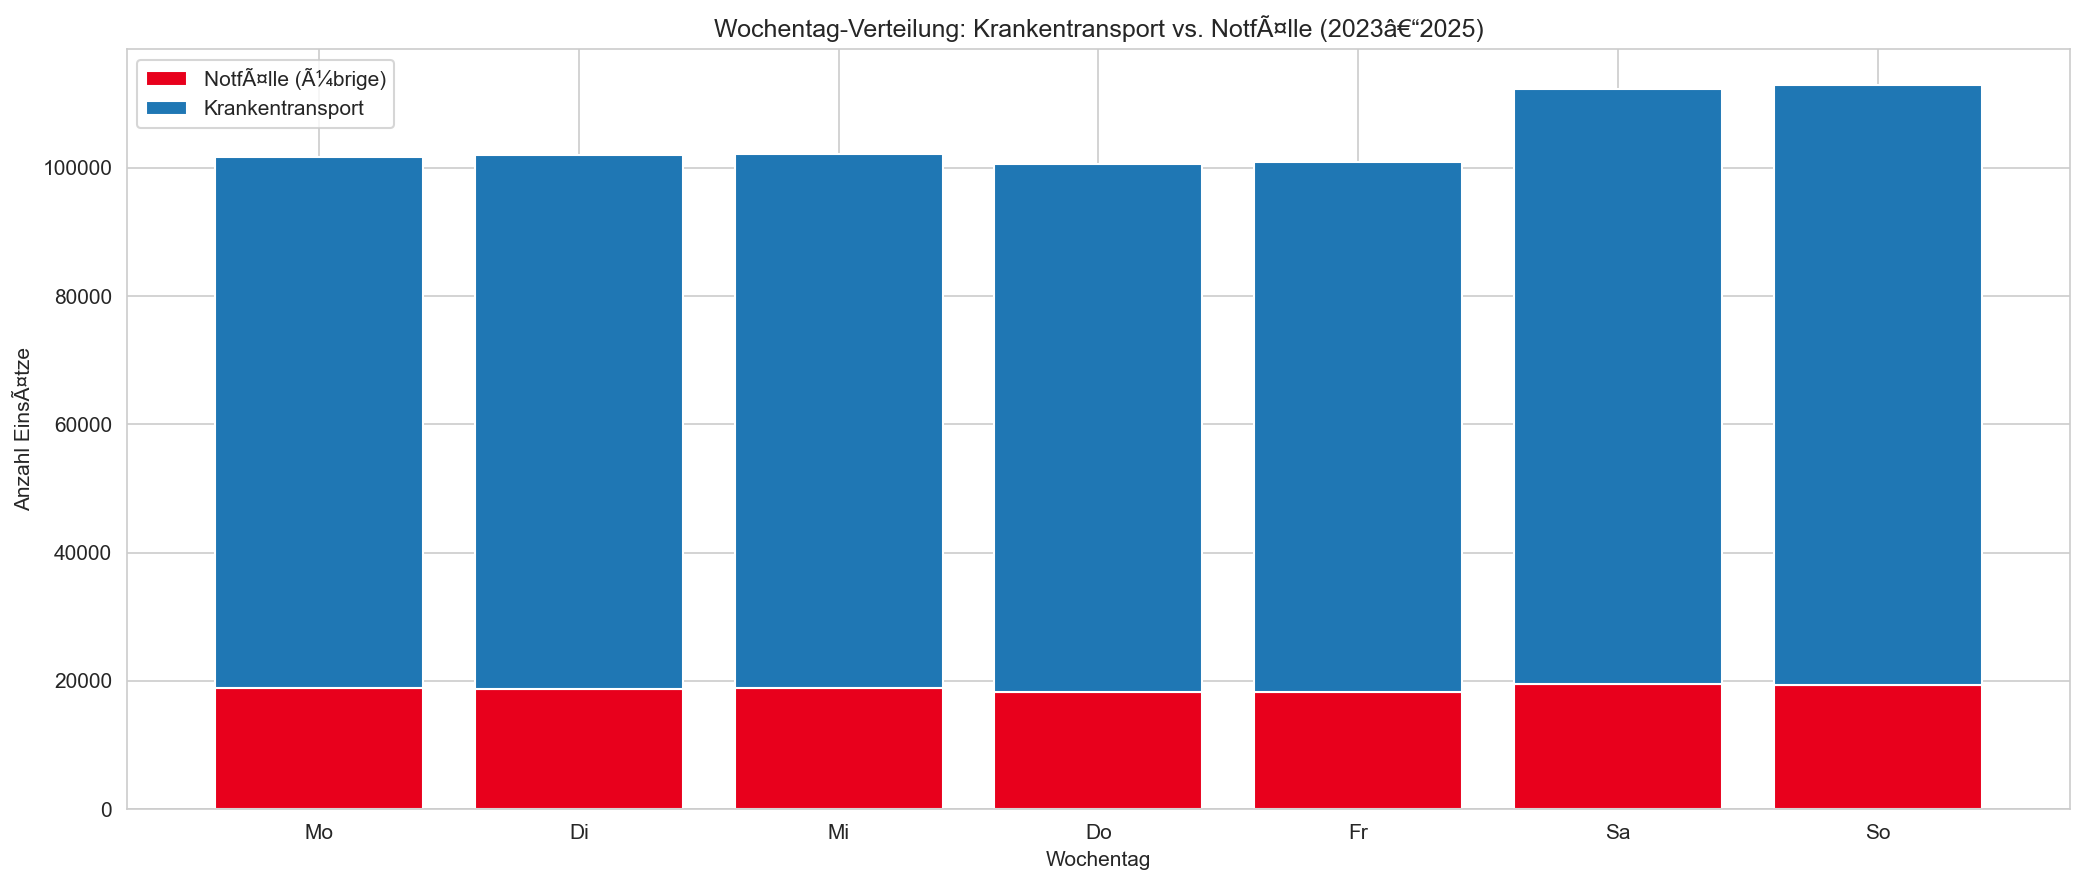

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_03.png


In [5]:
weekday_labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

wd_kt = df[is_kt].groupby('weekday').size().reindex(range(7), fill_value=0)
wd_notfall = df[~is_kt].groupby('weekday').size().reindex(range(7), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.bar(weekday_labels, wd_notfall.values, label='NotfÃ¤lle (Ã¼brige)', color='#E8001C')
ax.bar(weekday_labels, wd_kt.values, bottom=wd_notfall.values, label='Krankentransport', color='#1f77b4')

ax.set_title('Wochentag-Verteilung: Krankentransport vs. NotfÃ¤lle (2023â€“2025)')
ax.set_xlabel('Wochentag')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_03.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 4 â€“ Altersverteilung nach Einsatztyp (Top 5)

Top 5 Einsatztypen: ['Krankentransport', 'Sturz', 'Herz-Kreislauf', 'Atemnot', 'Verkehrsunfall']


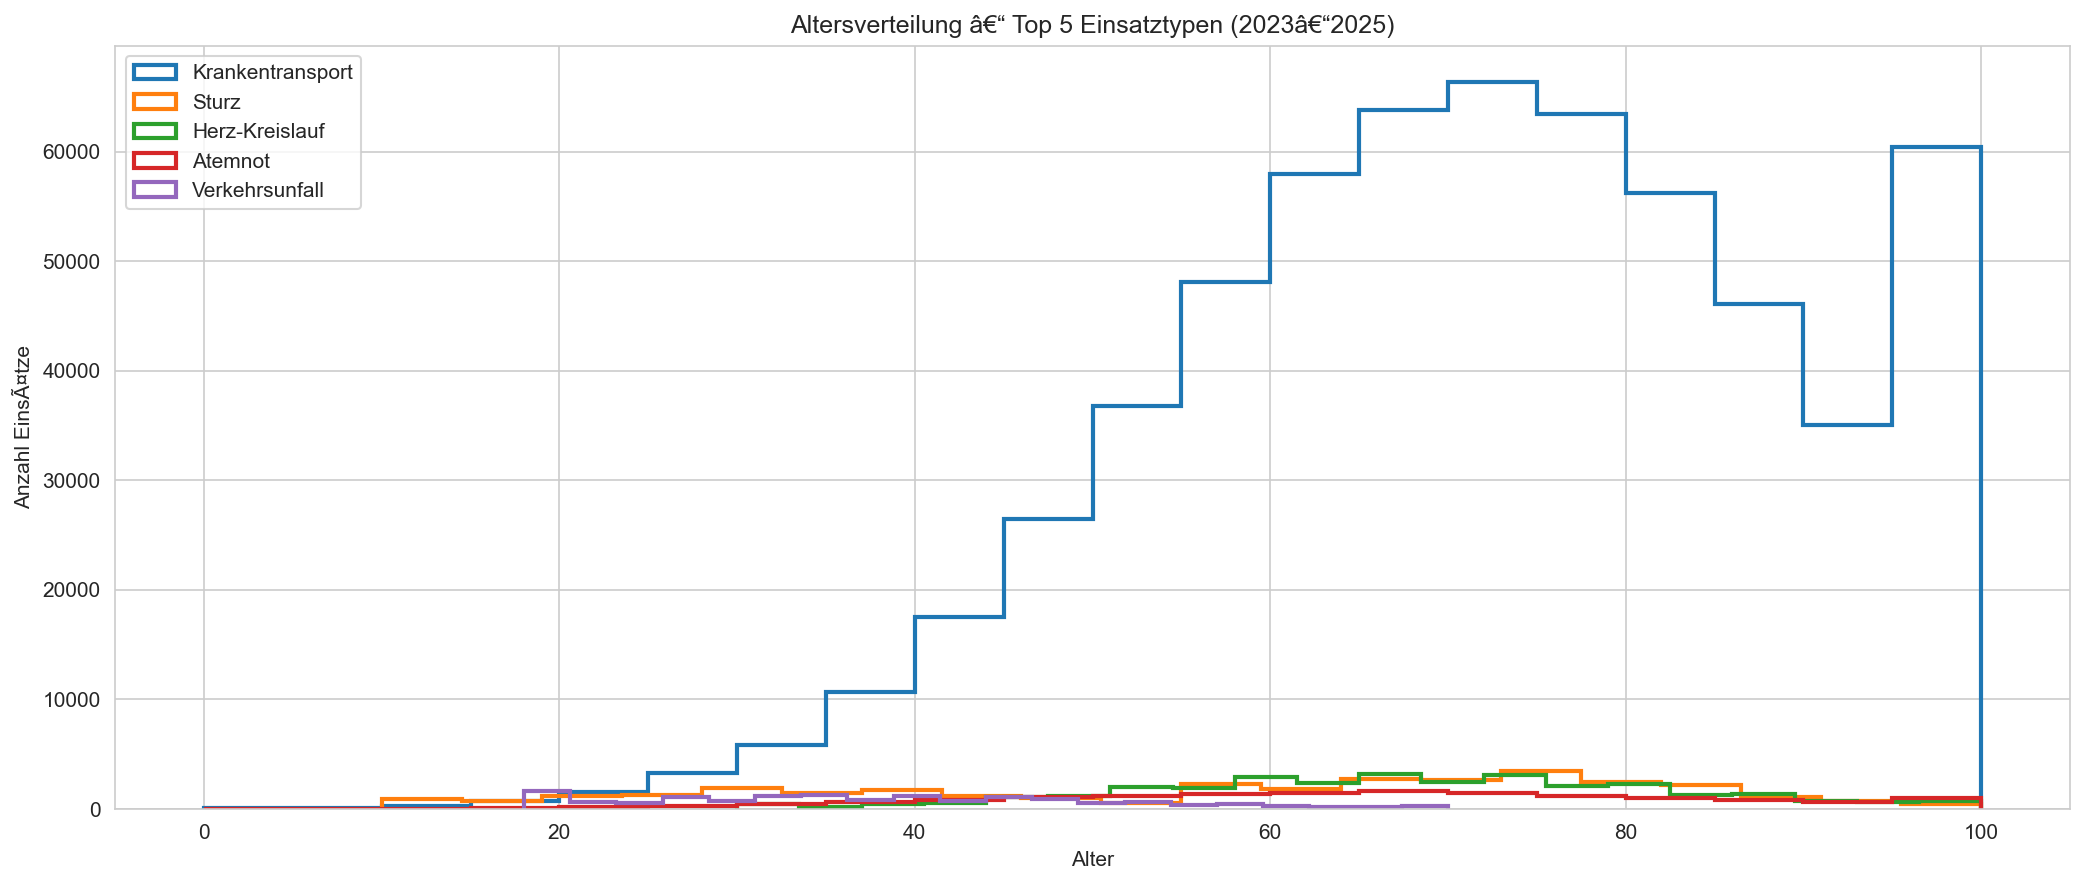

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_04.png


In [6]:
top5_types = df['type_name'].value_counts().head(5).index.tolist()
print(f'Top 5 Einsatztypen: {top5_types}')

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
colors = plt.cm.tab10.colors
for i, t in enumerate(top5_types):
    ages = df.loc[df['type_name'] == t, 'age']
    ax.hist(ages, bins=20, histtype='step', linewidth=2, label=t, color=colors[i])

ax.set_title('Altersverteilung â€“ Top 5 Einsatztypen (2023â€“2025)')
ax.set_xlabel('Alter')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_04.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 5 â€“ Geschlecht pro Einsatztyp (ohne Krankentransport)

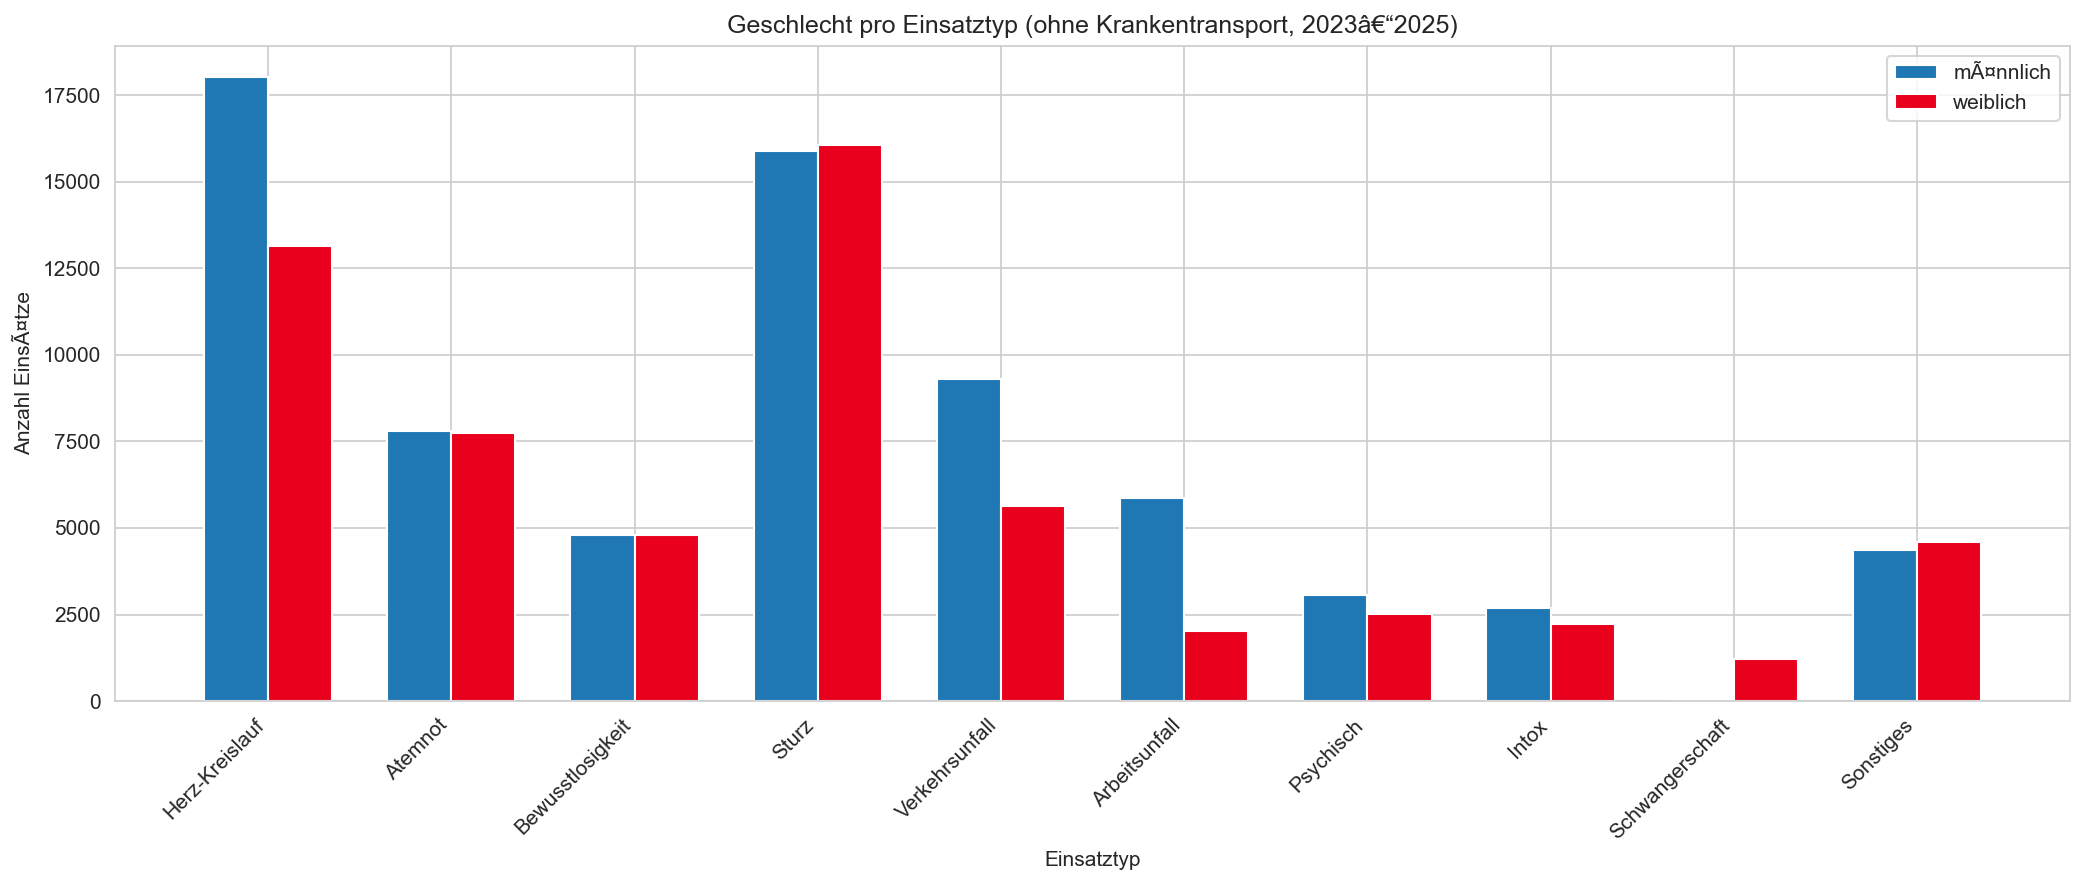

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_05.png


In [7]:
# Nur Typ 1-8 und 10-11 (Krankentransport = Typ 9 ausgeschlossen)
df_gender = df[df[TCOL] != 9]

gender_ct = pd.crosstab(df_gender['type_name'], df_gender['gender'])
# Sortierung nach urspruenglicher Typ-ID fuer konsistente Reihenfolge
order = [type_names[i] for i in sorted(type_names) if i != 9]
gender_ct = gender_ct.reindex(order)

x = np.arange(len(gender_ct))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.bar(x - width / 2, gender_ct.get('m', 0), width, label='mÃ¤nnlich', color='#1f77b4')
ax.bar(x + width / 2, gender_ct.get('w', 0), width, label='weiblich', color='#E8001C')

ax.set_title('Geschlecht pro Einsatztyp (ohne Krankentransport, 2023â€“2025)')
ax.set_xlabel('Einsatztyp')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.set_xticks(x)
ax.set_xticklabels(gender_ct.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_05.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 6 â€“ Location-Verteilung pro Einsatztyp (100% gestapelt)

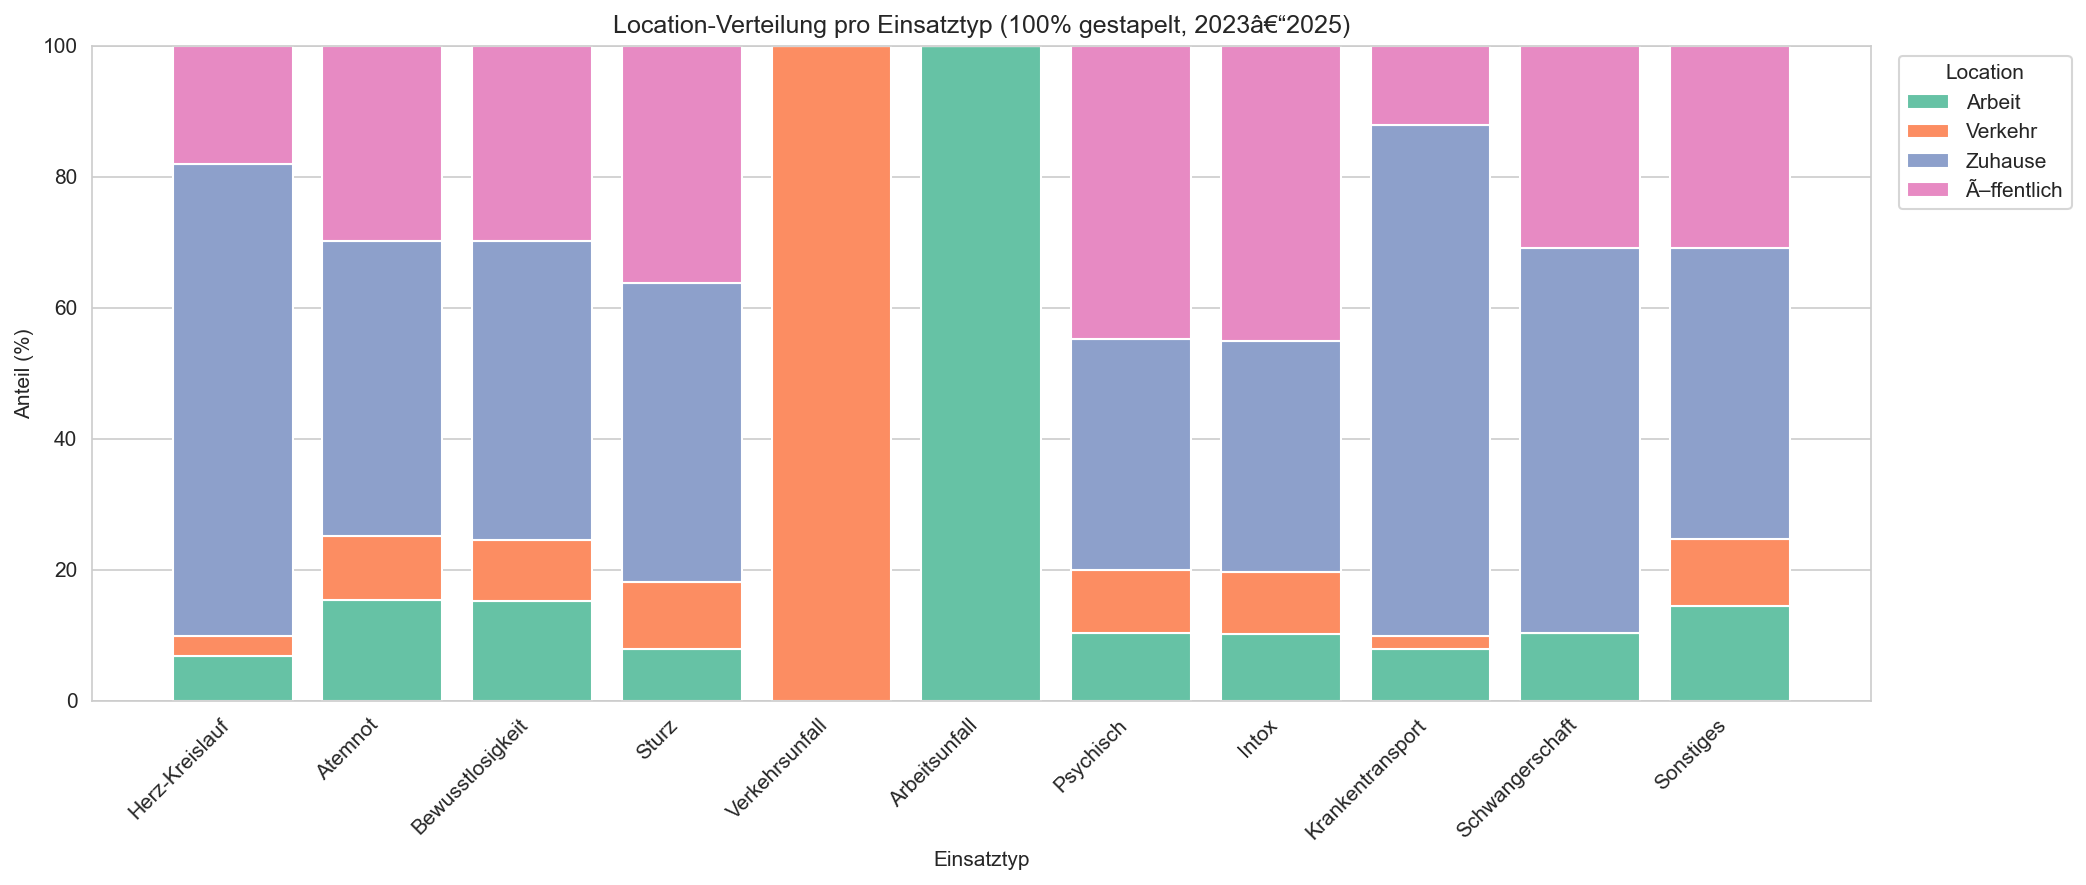

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_06.png


In [8]:
loc_ct = pd.crosstab(df['type_name'], df['loc_name'])
loc_ct = loc_ct.reindex([type_names[i] for i in sorted(type_names)])
loc_pct = loc_ct.div(loc_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
bottom = np.zeros(len(loc_pct))
colors = plt.cm.Set2.colors
for i, loc in enumerate(loc_pct.columns):
    ax.bar(loc_pct.index, loc_pct[loc], bottom=bottom, label=loc, color=colors[i % len(colors)])
    bottom += loc_pct[loc].values

ax.set_title('Location-Verteilung pro Einsatztyp (100% gestapelt, 2023â€“2025)')
ax.set_xlabel('Einsatztyp')
ax.set_ylabel('Anteil (%)')
ax.set_xticks(range(len(loc_pct.index)))
ax.set_xticklabels(loc_pct.index, rotation=45, ha='right')
ax.legend(title='Location', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_06.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 7 â€“ EinsÃ¤tze pro Gebiet

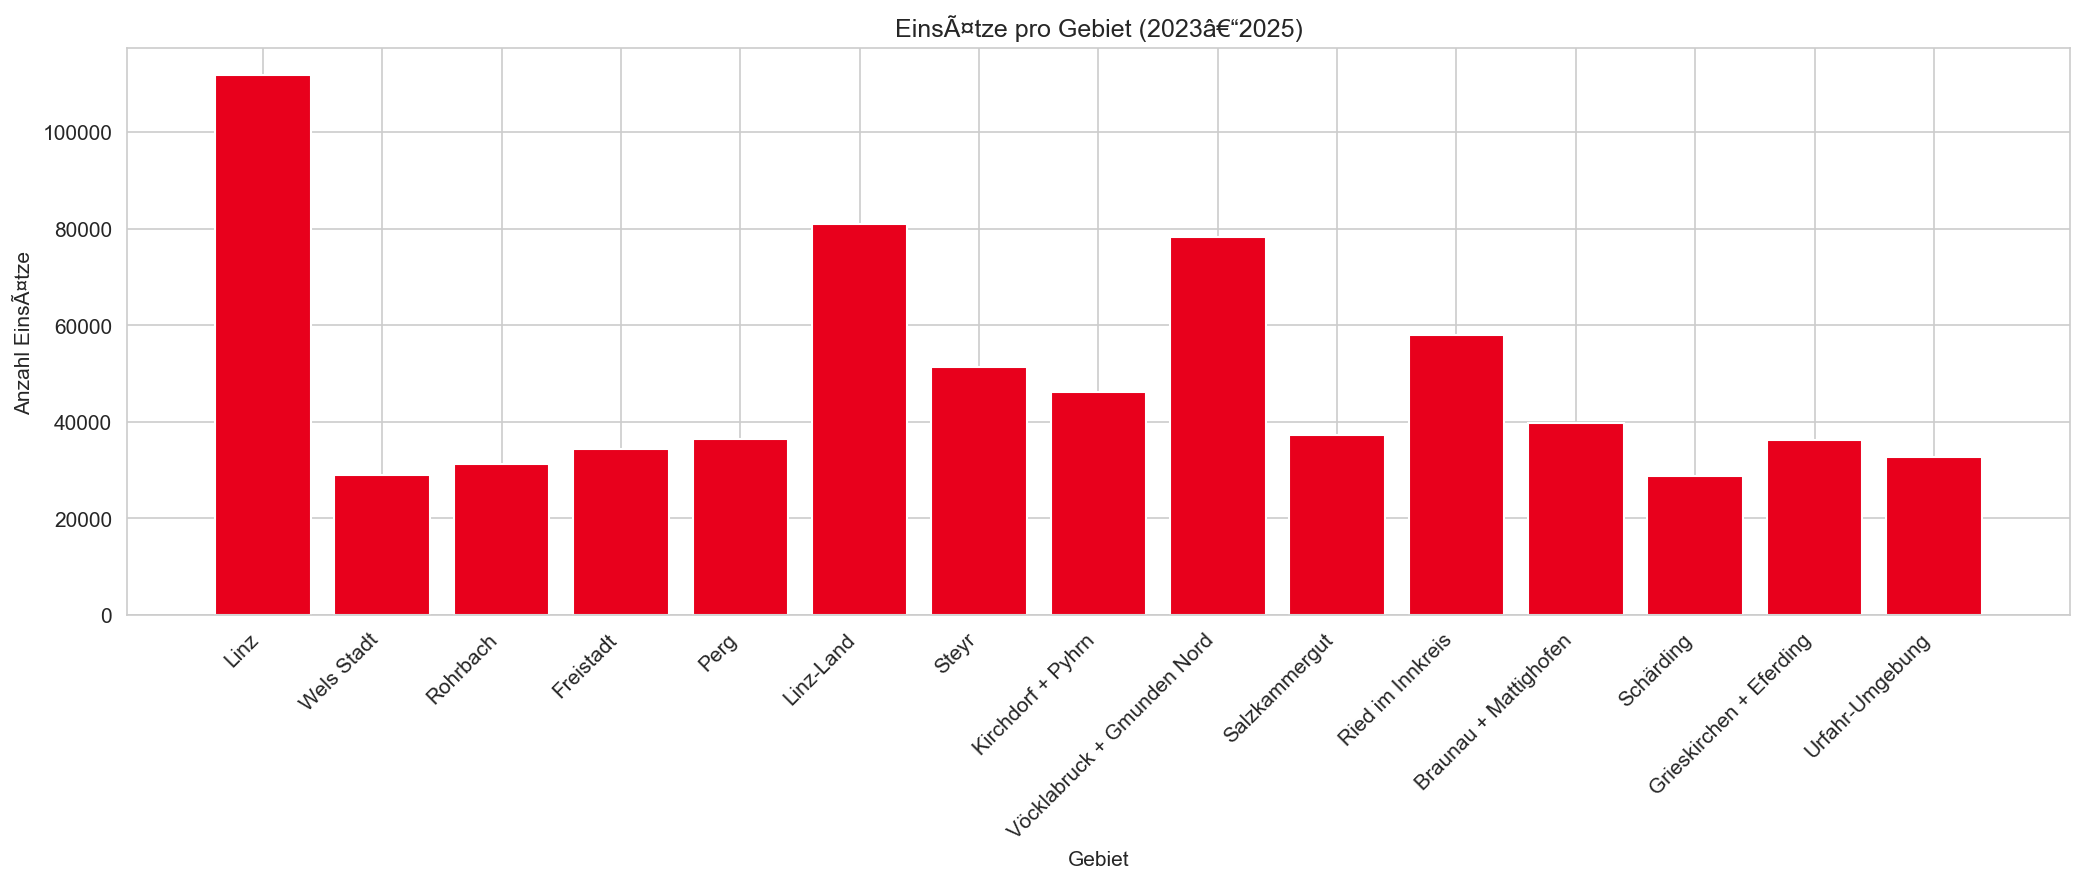

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_07.png


In [9]:
gebiet_counts = df[df['gebiet_id'] != -1].groupby('gebiet_id').size().sort_index()
gebiet_labels = [GEBIET_NAMES.get(g, str(g)) for g in gebiet_counts.index]

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.bar(gebiet_labels, gebiet_counts.values, color='#E8001C')

ax.set_title('EinsÃ¤tze pro Gebiet (2023â€“2025)')
ax.set_xlabel('Gebiet')
ax.set_ylabel('Anzahl EinsÃ¤tze')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_07.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 8 â€“ Zeitlicher Verlauf 2023â€“2025 (7-Tage-GlÃ¤ttung)

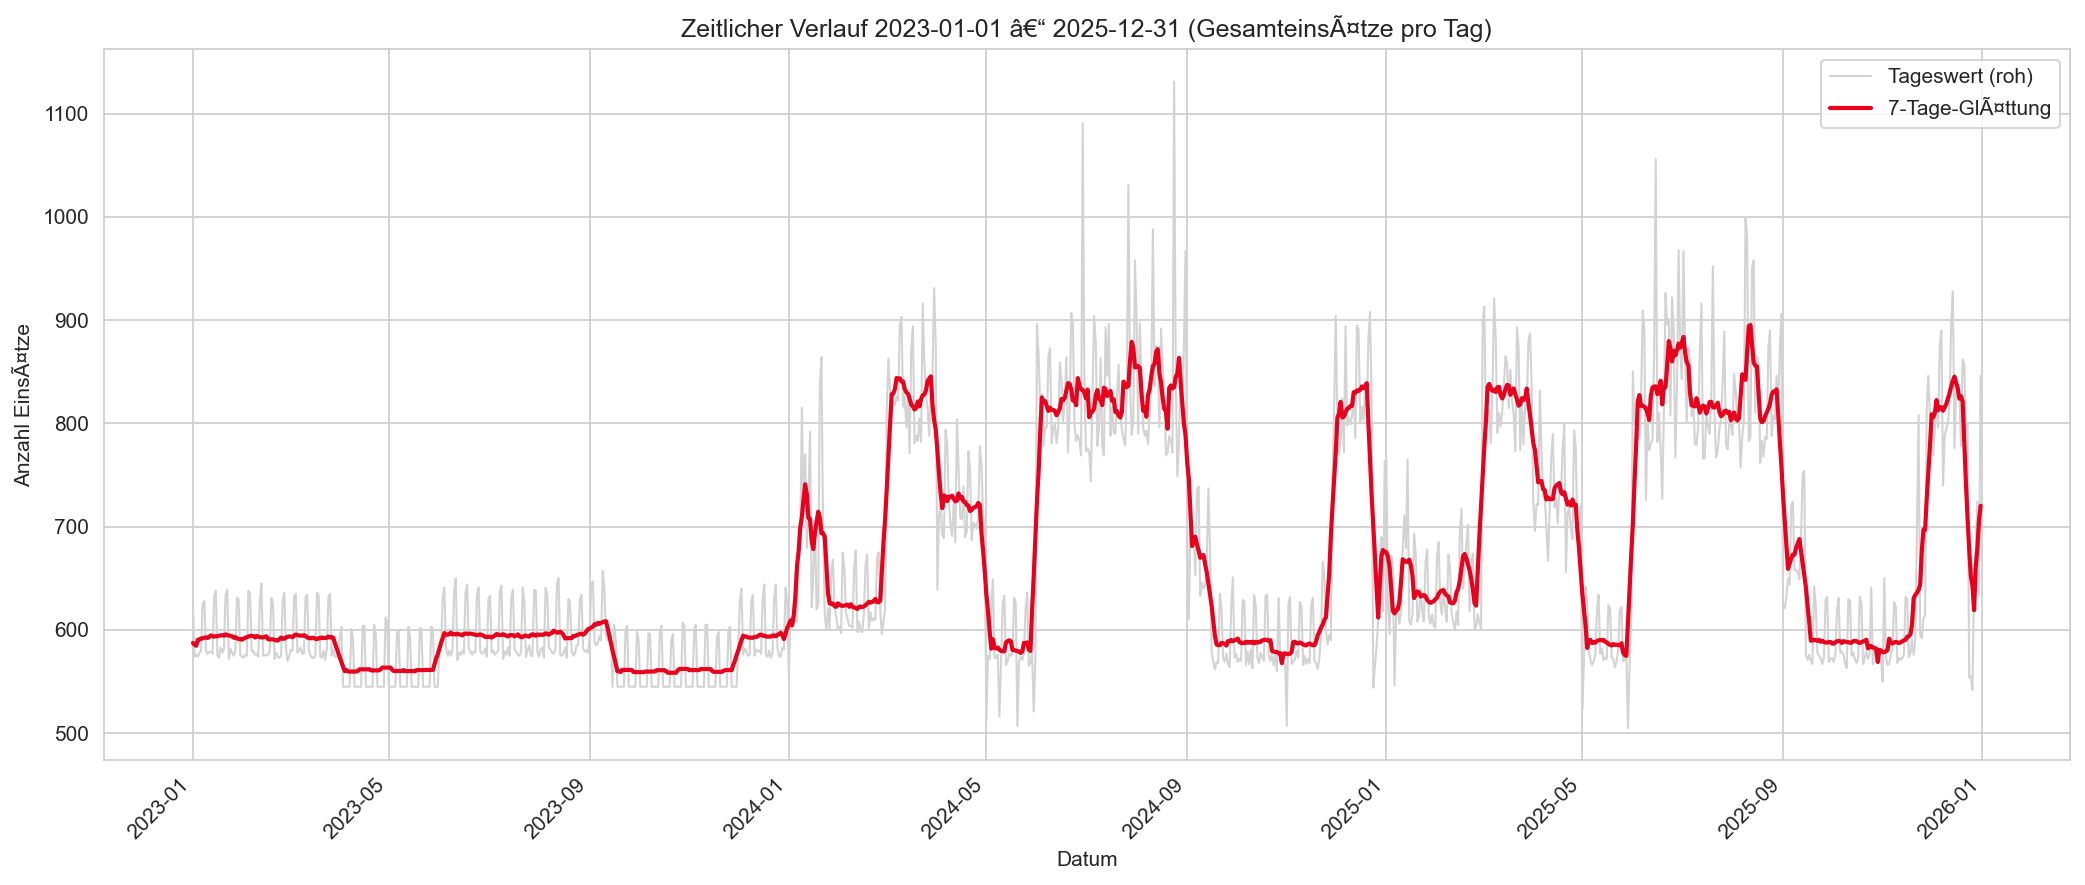

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_08.png


In [10]:
daily = df.groupby('date').size().sort_index()
daily_smooth = daily.rolling(window=7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.plot(daily.index, daily.values, color='lightgray', linewidth=1, label='Tageswert (roh)')
ax.plot(daily_smooth.index, daily_smooth.values, color='#E8001C', linewidth=2, label='7-Tage-GlÃ¤ttung')

ax.set_title(f'Zeitlicher Verlauf {df["date"].min().date()} â€“ {df["date"].max().date()} (GesamteinsÃ¤tze pro Tag)')
ax.set_xlabel('Datum')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_08.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 9 â€“ Heatmap Wochentag Ã— Stunde

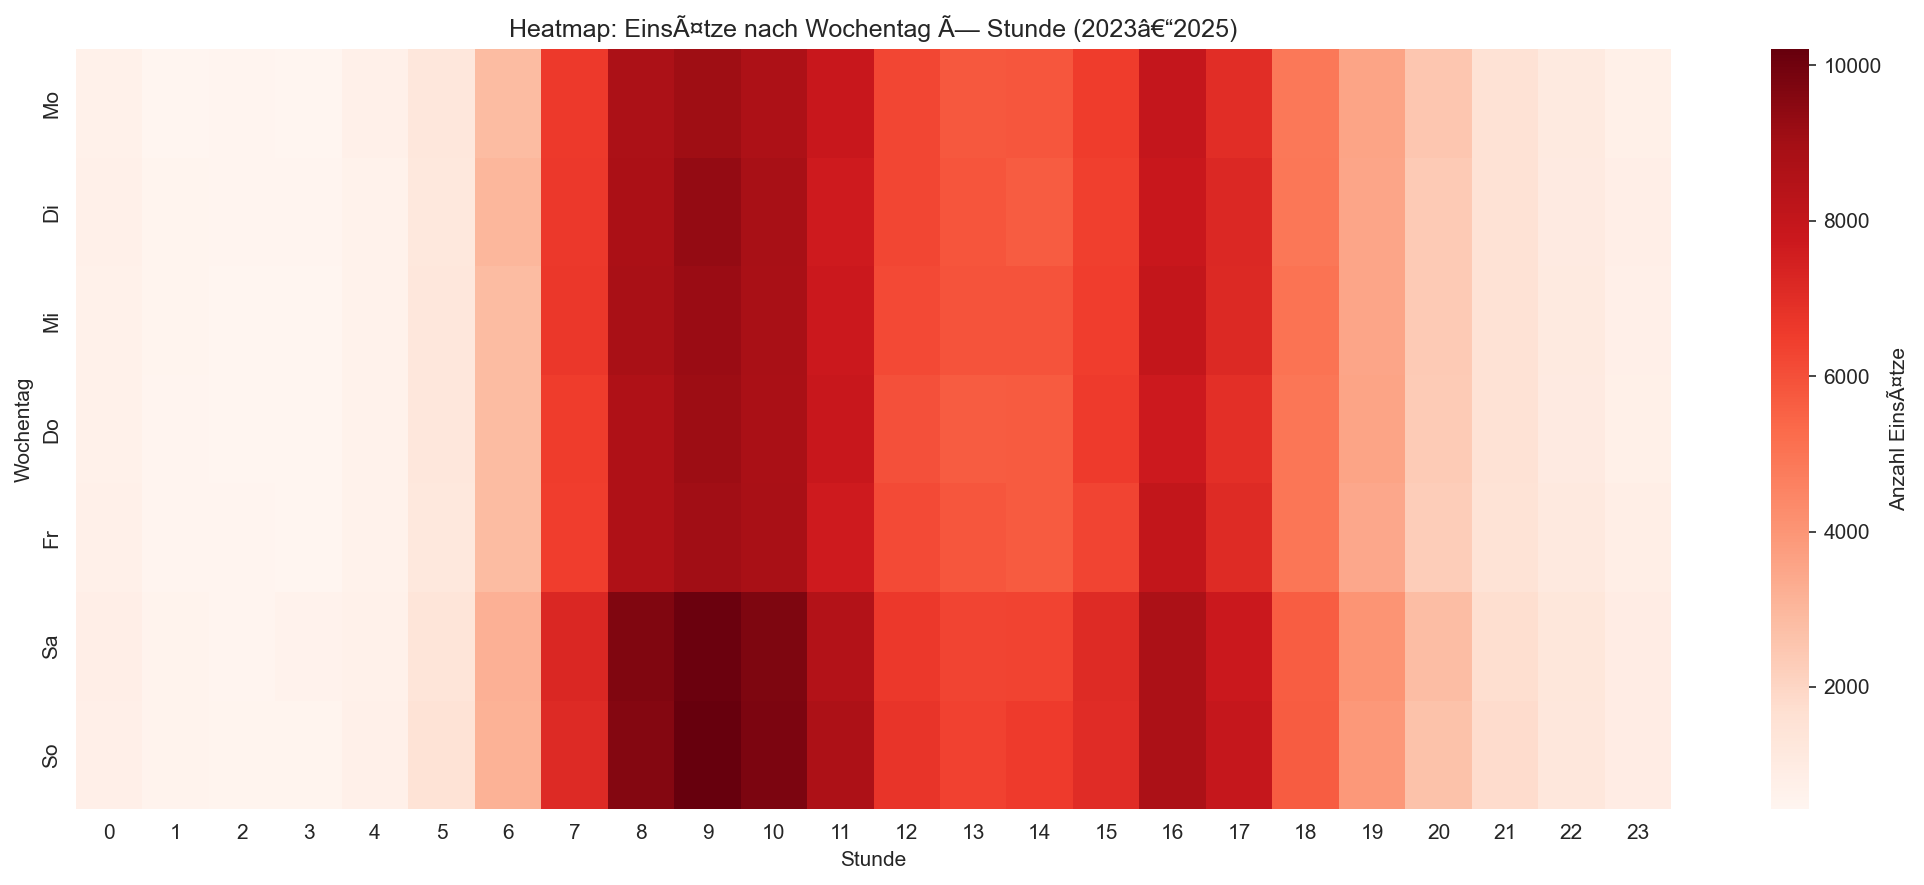

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_gesamt_09.png


In [11]:
heat_data = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0).reindex(range(7))
heat_data.index = weekday_labels

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
sns.heatmap(heat_data, cmap='Reds', ax=ax, cbar_kws={'label': 'Anzahl EinsÃ¤tze'})

ax.set_title('Heatmap: EinsÃ¤tze nach Wochentag Ã— Stunde (2023â€“2025)')
ax.set_xlabel('Stunde')
ax.set_ylabel('Wochentag')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_gesamt_09.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 10 â€“ Constraint-Check (PlausibilitÃ¤t)

In [12]:
constraints = [
    ('Schwangerschaft bei MÃ¤nnern (soll 0)',
     ((df[TCOL] == 10) & (df['gender'] == 'm')).sum()),
    ('Arbeitsunfall nicht bei Arbeit (soll 0)',
     ((df[TCOL] == 6) & (df[LCOL] != 3)).sum()),
    ('Verkehrsunfall nicht bei Verkehr (soll 0)',
     ((df[TCOL] == 5) & (df[LCOL] != 4)).sum()),
]

check_df = pd.DataFrame(constraints, columns=['Constraint', 'Verletzungen'])
check_df['Status'] = check_df['Verletzungen'].apply(lambda n: 'OK' if n == 0 else 'FEHLER')

print(check_df.to_string(index=False))

                               Constraint  Verletzungen Status
    Schwangerschaft bei MÃ¤nnern (soll 0)             0     OK
  Arbeitsunfall nicht bei Arbeit (soll 0)             0     OK
Verkehrsunfall nicht bei Verkehr (soll 0)             0     OK


## Zusammenfassung â€“ Gesamtdatensatz

In [13]:
print('=== Zusammenfassung: Validierung Gesamt (2023â€“2025) ===')
print(f'Zeitraum:               {df["date"].min().date()} bis {df["date"].max().date()}')
print(f'Gesamtanzahl EinsÃ¤tze:  {len(df)}')
print(f'Nicht gemappte PLZ:     {(df["gebiet_id"] == -1).sum()}')
print(f'Anteil Krankentransport:{is_kt.mean() * 100:.1f}%')
print(f'Anteil NotfÃ¤lle:        {(~is_kt).mean() * 100:.1f}%')
print(f'Altersspanne:           {df["age"].min()}â€“{df["age"].max()} Jahre (Median {df["age"].median():.0f})')
print(f'Geschlechterverteilung: m={(df["gender"] == "m").mean()*100:.1f}%  w={(df["gender"] == "w").mean()*100:.1f}%')
print(f'HÃ¤ufigster Einsatztyp:  {df["type_name"].value_counts().idxmax()} ({df["type_name"].value_counts().max()} EinsÃ¤tze)')
print(f'HÃ¤ufigstes Gebiet:      {GEBIET_NAMES.get(gebiet_counts.idxmax())} ({gebiet_counts.max()} EinsÃ¤tze)')
print(f'Constraint-Verletzungen: {check_df["Verletzungen"].sum()} (von 3 Checks)')

=== Zusammenfassung: Validierung Gesamt (2023â€“2025) ===
Zeitraum:               2023-01-01 bis 2025-12-31
Gesamtanzahl EinsÃ¤tze:  732387
Nicht gemappte PLZ:     0
Anteil Krankentransport:82.0%
Anteil NotfÃ¤lle:        18.0%
Altersspanne:           0â€“100 Jahre (Median 69)
Geschlechterverteilung: m=49.2%  w=50.8%
HÃ¤ufigster Einsatztyp:  Krankentransport (600663 EinsÃ¤tze)
HÃ¤ufigstes Gebiet:      Linz (111728 EinsÃ¤tze)
Constraint-Verletzungen: 0 (von 3 Checks)


# Jahres- und Saisonvergleiche

Die folgenden Diagramme vergleichen die drei Jahre (2023, 2024, 2025) sowie die vier
Jahreszeiten direkt miteinander, um Konsistenz und saisonale Muster im Gesamtdatensatz
zu prÃ¼fen.

## V1 â€“ Jahresvergleich Gesamtvolumen

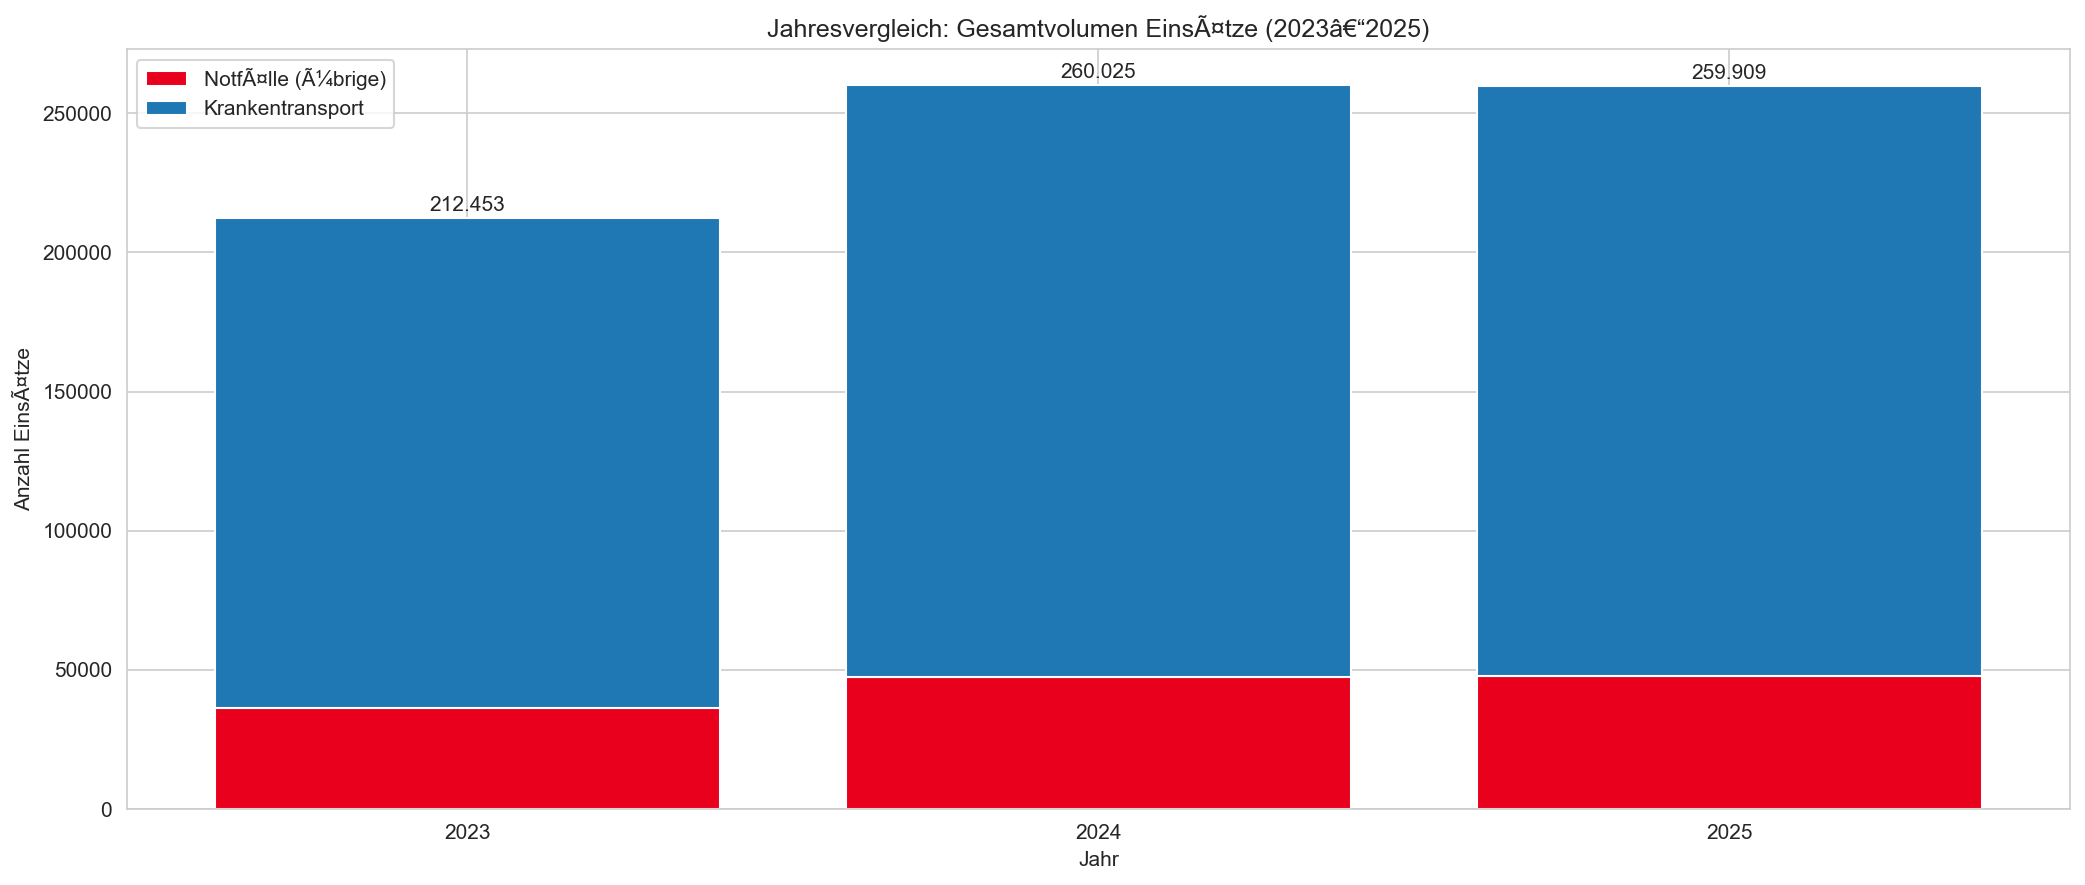

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_01.png


In [14]:
years = [2023, 2024, 2025]
year_kt = df[is_kt].groupby('year').size().reindex(years, fill_value=0)
year_notfall = df[~is_kt].groupby('year').size().reindex(years, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
year_labels = [str(y) for y in years]
bars_notfall = ax.bar(year_labels, year_notfall.values, label='NotfÃ¤lle (Ã¼brige)', color='#E8001C')
bars_kt = ax.bar(year_labels, year_kt.values, bottom=year_notfall.values, label='Krankentransport', color='#1f77b4')

totals = year_kt.values + year_notfall.values
for label, total in zip(year_labels, totals):
    ax.text(label, total + totals.max() * 0.01, f'{total:,}'.replace(',', '.'), ha='center', fontsize=10)

ax.set_title('Jahresvergleich: Gesamtvolumen EinsÃ¤tze (2023â€“2025)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_01.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V2 â€“ Saisonvergleich Einsatztypen

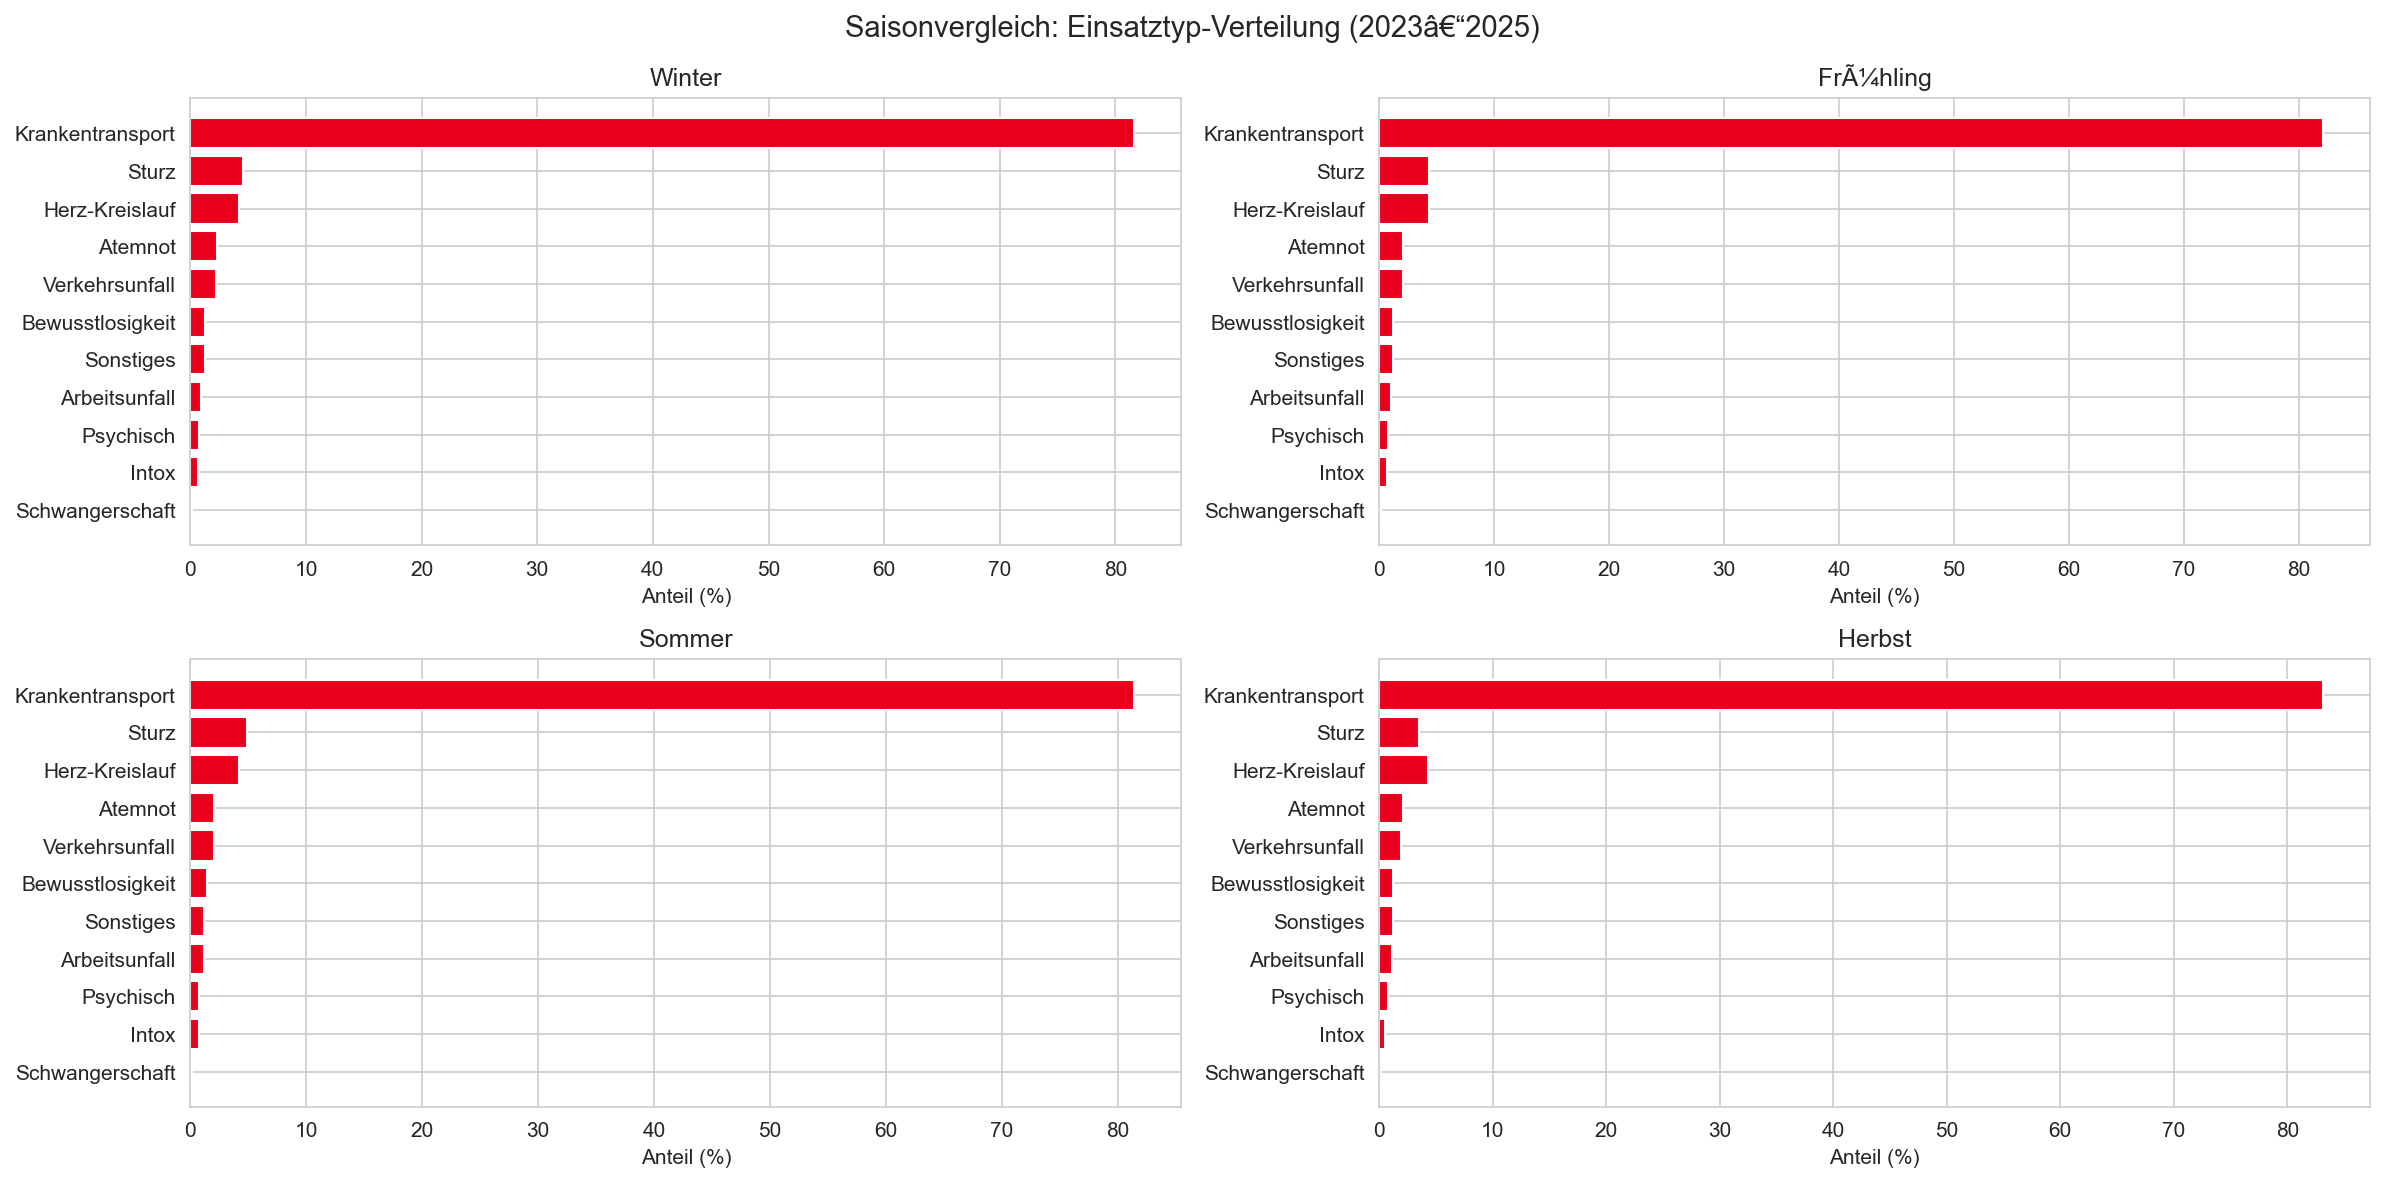

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_02.png


In [15]:
type_order = df['type_name'].value_counts().sort_values(ascending=True).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 8), dpi=150)
for ax, season_id in zip(axes.flat, [0, 1, 2, 3]):
    sub = df[df['season'] == season_id]
    counts = sub['type_name'].value_counts().reindex(type_order, fill_value=0)
    pct = counts / counts.sum() * 100
    ax.barh(pct.index, pct.values, color='#E8001C')
    ax.set_title(season_names[season_id])
    ax.set_xlabel('Anteil (%)')

fig.suptitle('Saisonvergleich: Einsatztyp-Verteilung (2023â€“2025)', fontsize=14)
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_02.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V3 â€“ Jahresverlauf aller 3 Jahre Ã¼berlagert

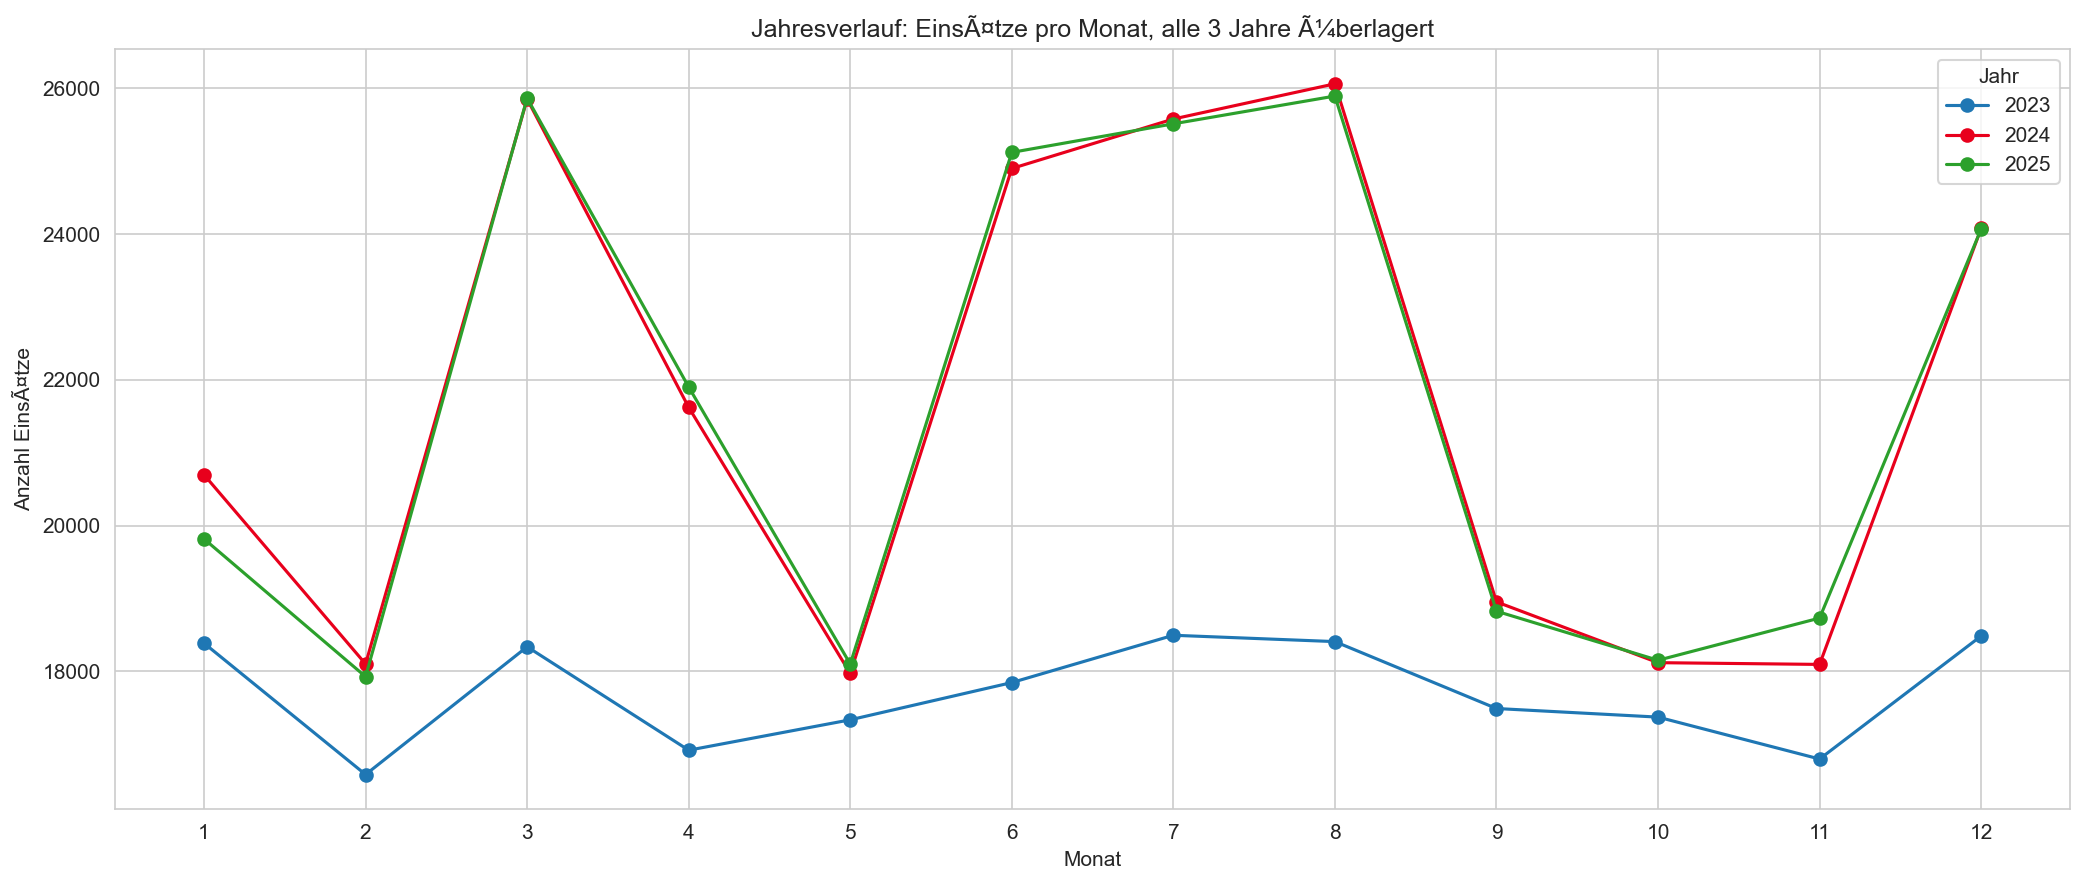

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_03.png


In [16]:
monthly = df.groupby(['year', 'month']).size().unstack('year', fill_value=0)
colors = {2023: '#1f77b4', 2024: '#E8001C', 2025: '#2ca02c'}

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
for year in years:
    sub = monthly[year].reindex(range(1, 13), fill_value=0) if year in monthly.columns else pd.Series(0, index=range(1, 13))
    ax.plot(range(1, 13), sub.values, marker='o', label=str(year), color=colors[year])

ax.set_title('Jahresverlauf: EinsÃ¤tze pro Monat, alle 3 Jahre Ã¼berlagert')
ax.set_xlabel('Monat')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.set_xticks(range(1, 13))
ax.legend(title='Jahr')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_03.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V4 â€“ Saisonaler Einsatztyp-Shift (Heatmap)

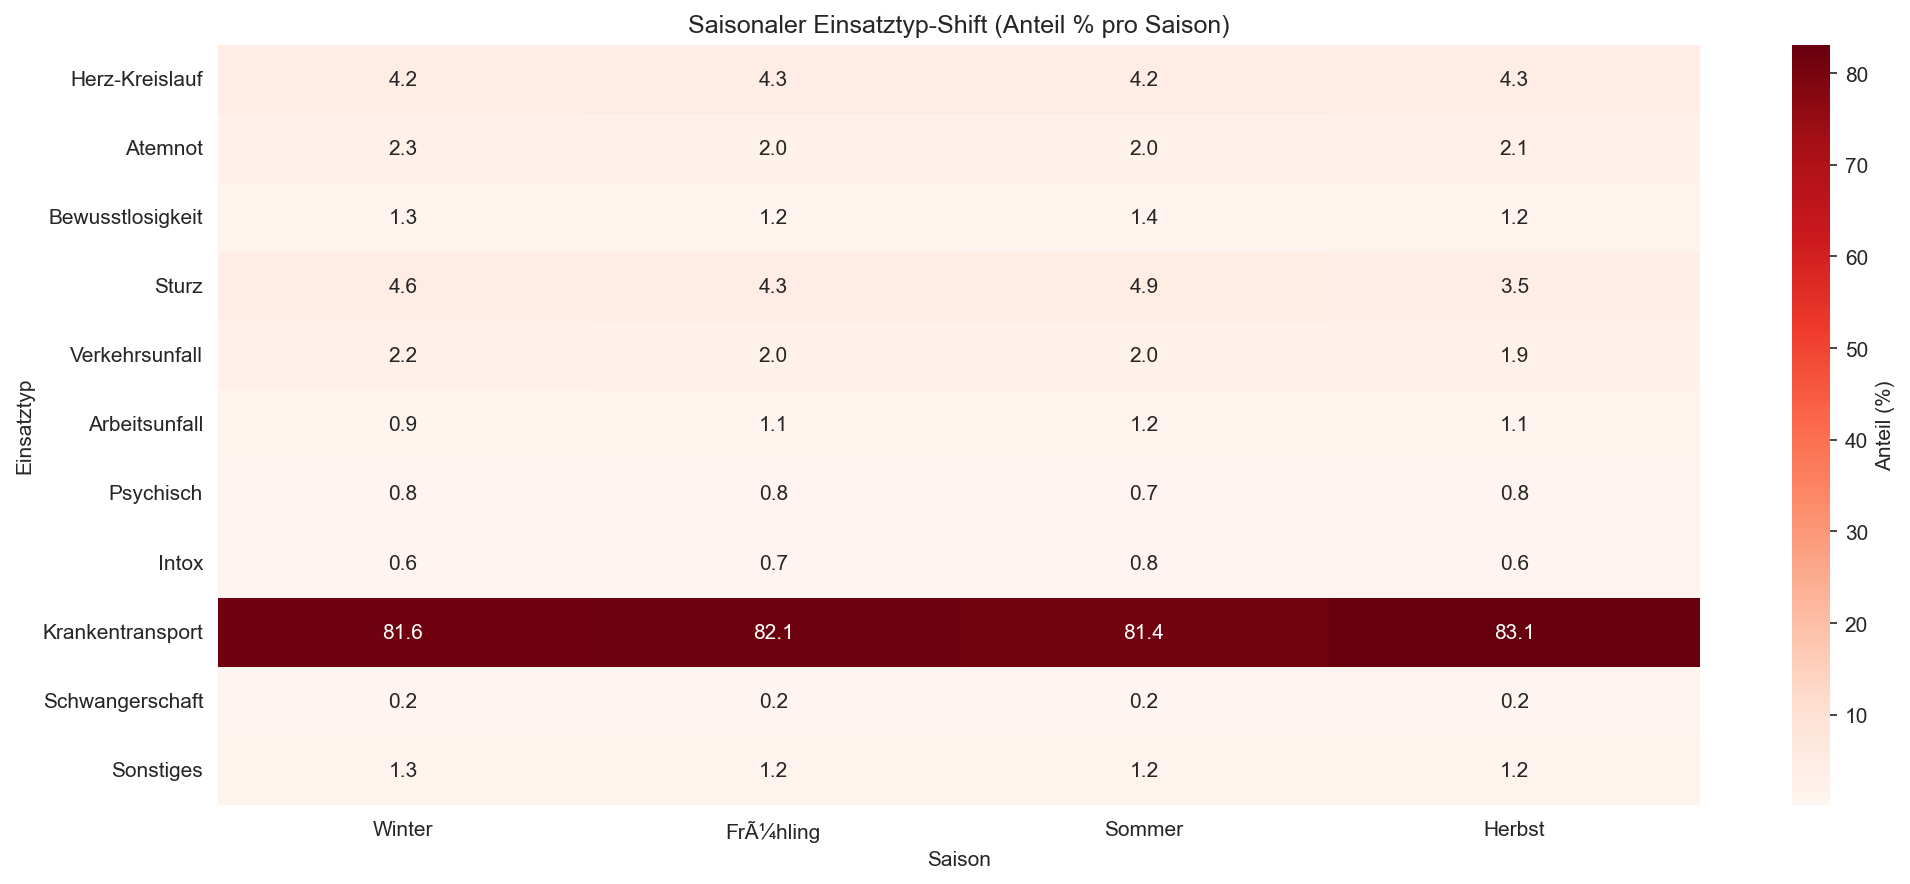

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_04.png


In [17]:
season_type_ct = pd.crosstab(df['type_name'], df['season_name'])
season_type_ct = season_type_ct.reindex(columns=SEASON_ORDER)
season_type_pct = season_type_ct.div(season_type_ct.sum(axis=0), axis=1) * 100
season_type_pct = season_type_pct.reindex([type_names[i] for i in sorted(type_names)])

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
sns.heatmap(season_type_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': 'Anteil (%)'})

ax.set_title('Saisonaler Einsatztyp-Shift (Anteil % pro Saison)')
ax.set_xlabel('Saison')
ax.set_ylabel('Einsatztyp')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_04.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V5 â€“ Tageszeit-Kurven nach Saison (nur Krankentransport)

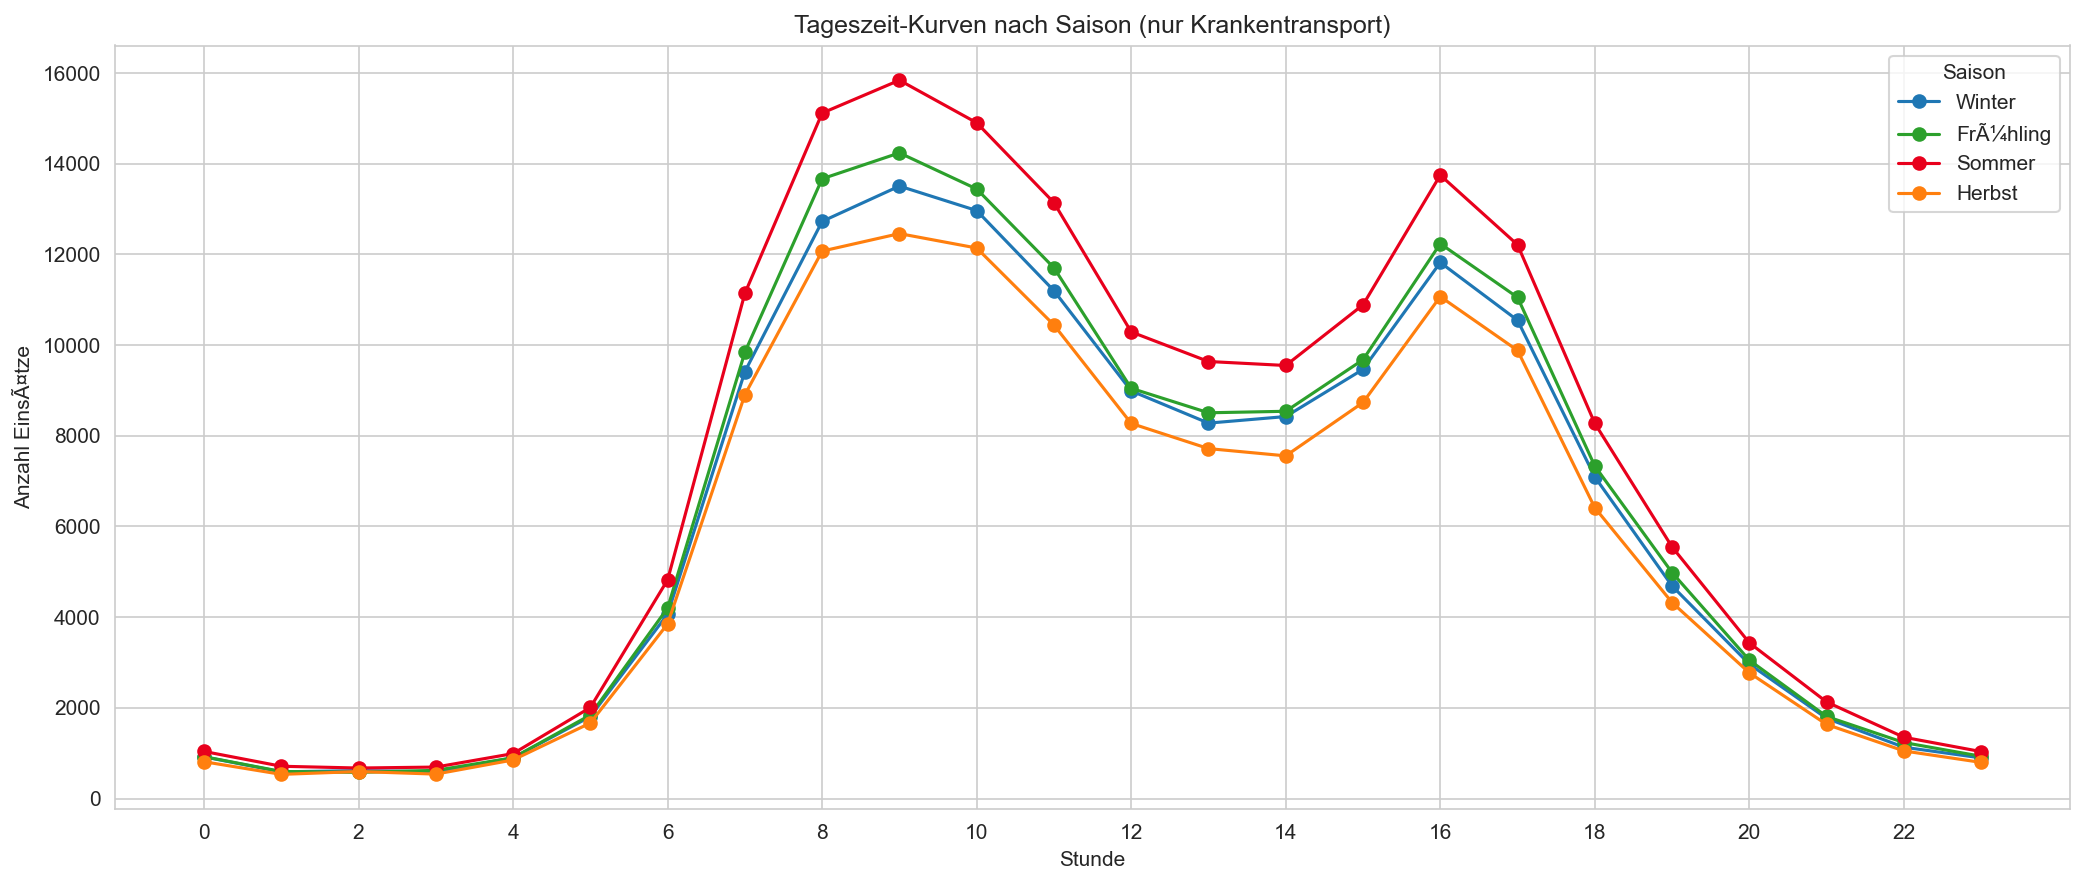

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_05.png


In [18]:
kt_df = df[is_kt]
season_colors = {0: '#1f77b4', 1: '#2ca02c', 2: '#E8001C', 3: '#ff7f0e'}

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
for season_id in [0, 1, 2, 3]:
    sub = kt_df[kt_df['season'] == season_id]
    hourly = sub.groupby('hour').size().reindex(range(24), fill_value=0)
    ax.plot(hourly.index, hourly.values, marker='o', label=season_names[season_id], color=season_colors[season_id])

ax.set_title('Tageszeit-Kurven nach Saison (nur Krankentransport)')
ax.set_xlabel('Stunde')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.set_xticks(range(0, 24, 2))
ax.legend(title='Saison')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_05.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V6 â€“ Gebietsvergleich nach Saison

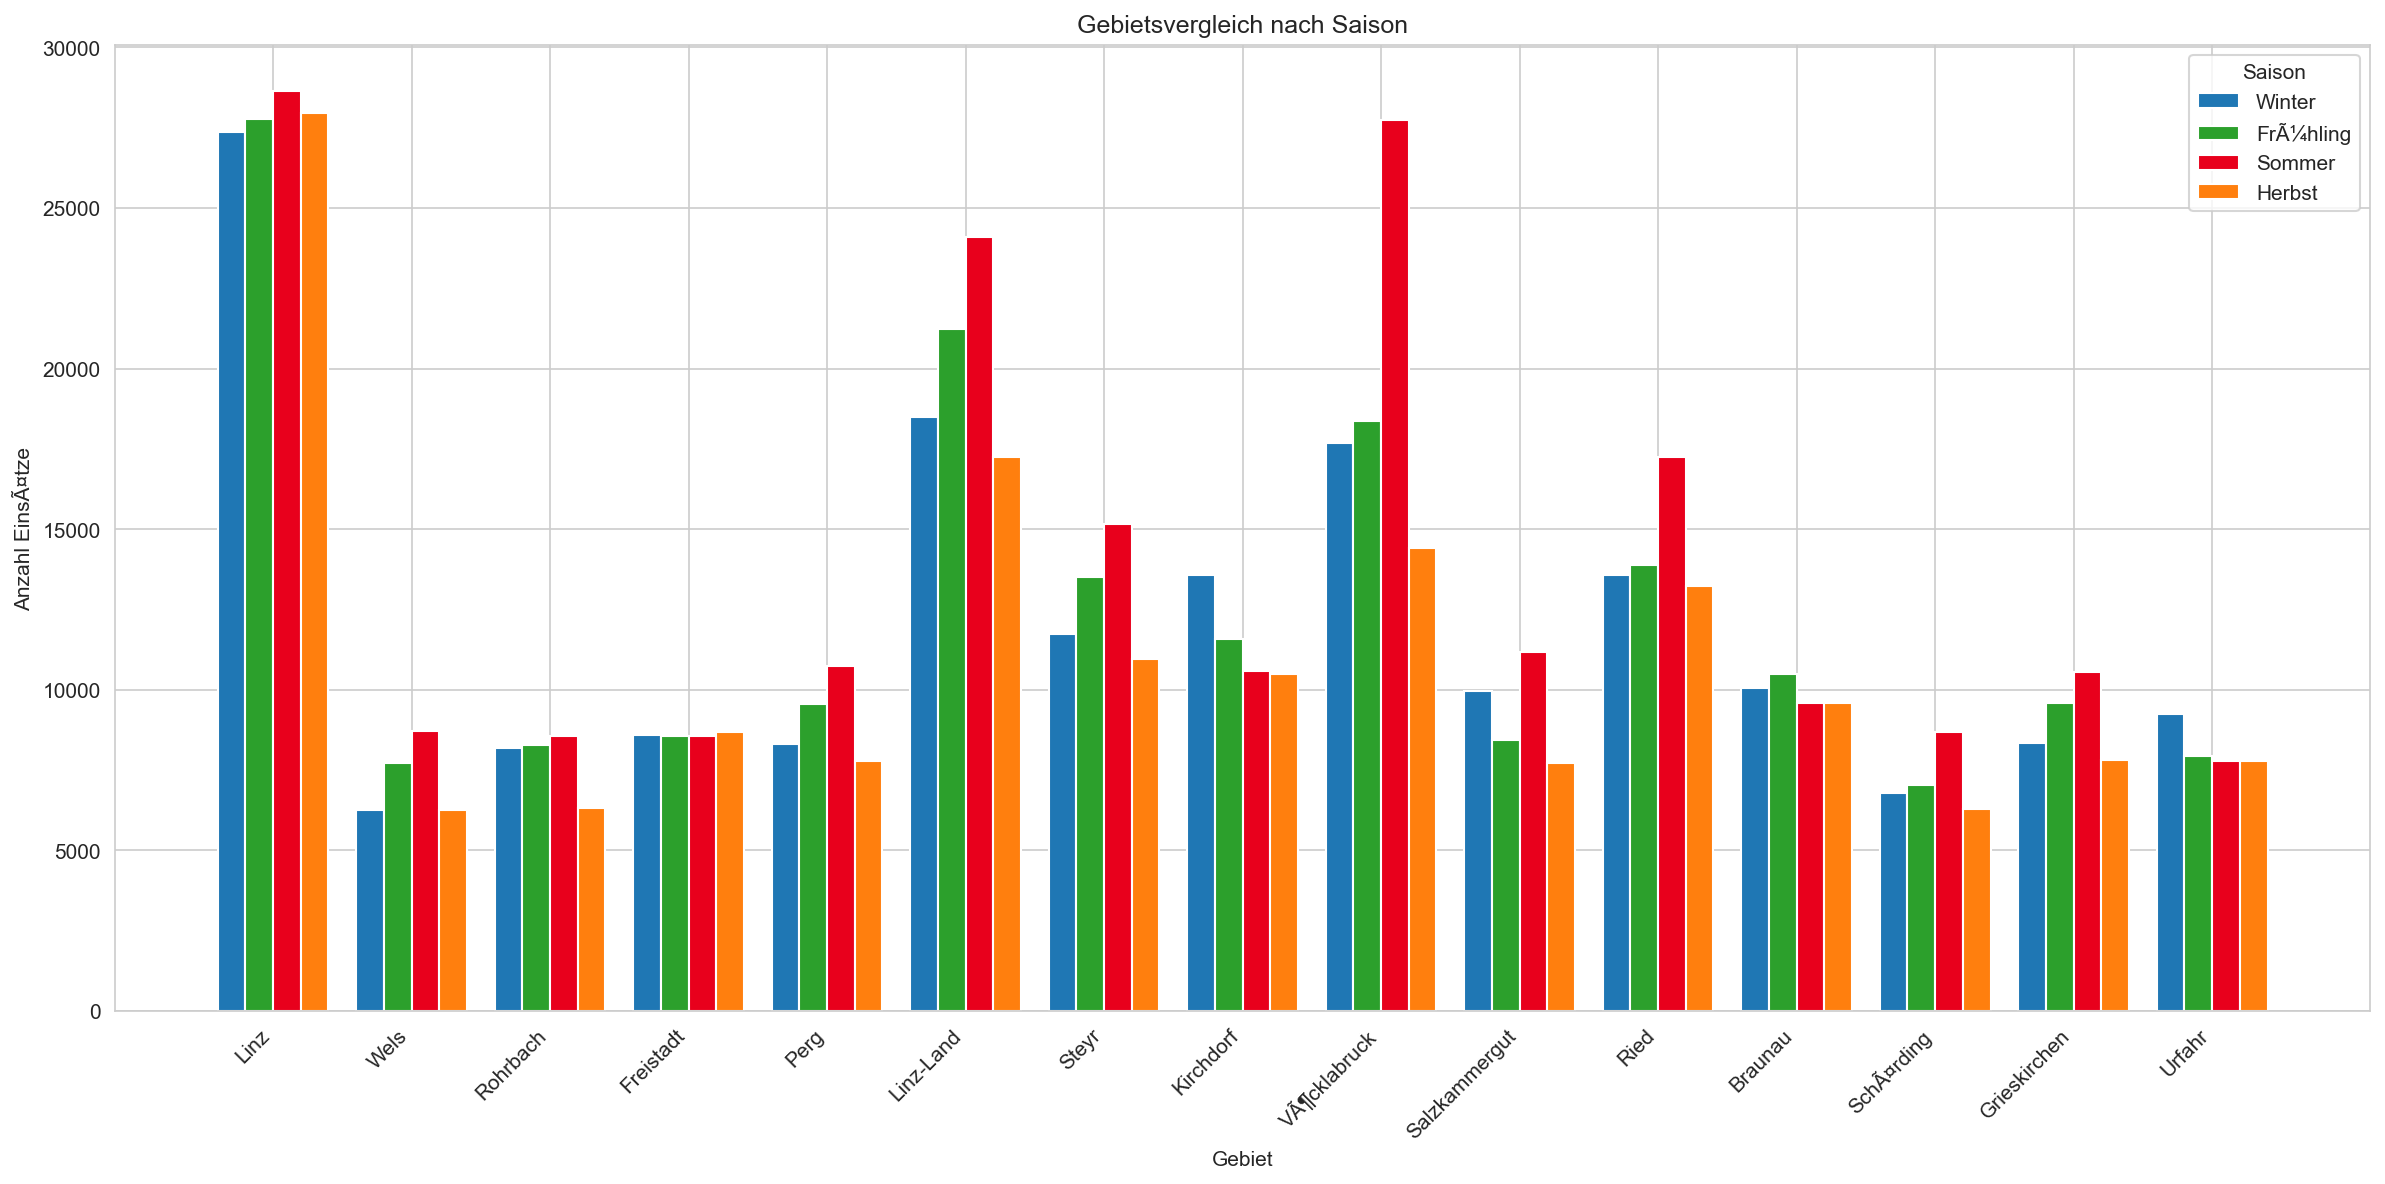

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_06.png


In [19]:
gebiet_season_ct = df[df['gebiet_id'] != -1].groupby(['gebiet_id', 'season']).size().unstack('season', fill_value=0)
gebiet_season_ct = gebiet_season_ct.reindex(columns=[0, 1, 2, 3], fill_value=0).sort_index()

x = np.arange(len(gebiet_season_ct))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 8), dpi=150)
for i, season_id in enumerate([0, 1, 2, 3]):
    ax.bar(x + (i - 1.5) * width, gebiet_season_ct[season_id].values, width,
           label=season_names[season_id], color=season_colors[season_id])

ax.set_title('Gebietsvergleich nach Saison')
ax.set_xlabel('Gebiet')
ax.set_ylabel('Anzahl EinsÃ¤tze')
ax.set_xticks(x)
ax.set_xticklabels([GEBIET_KURZ.get(g, str(g)) for g in gebiet_season_ct.index], rotation=45, ha='right')
ax.legend(title='Saison')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_06.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V7 â€“ Altersverteilung nach Saison (ausgewÃ¤hlte Einsatztypen)

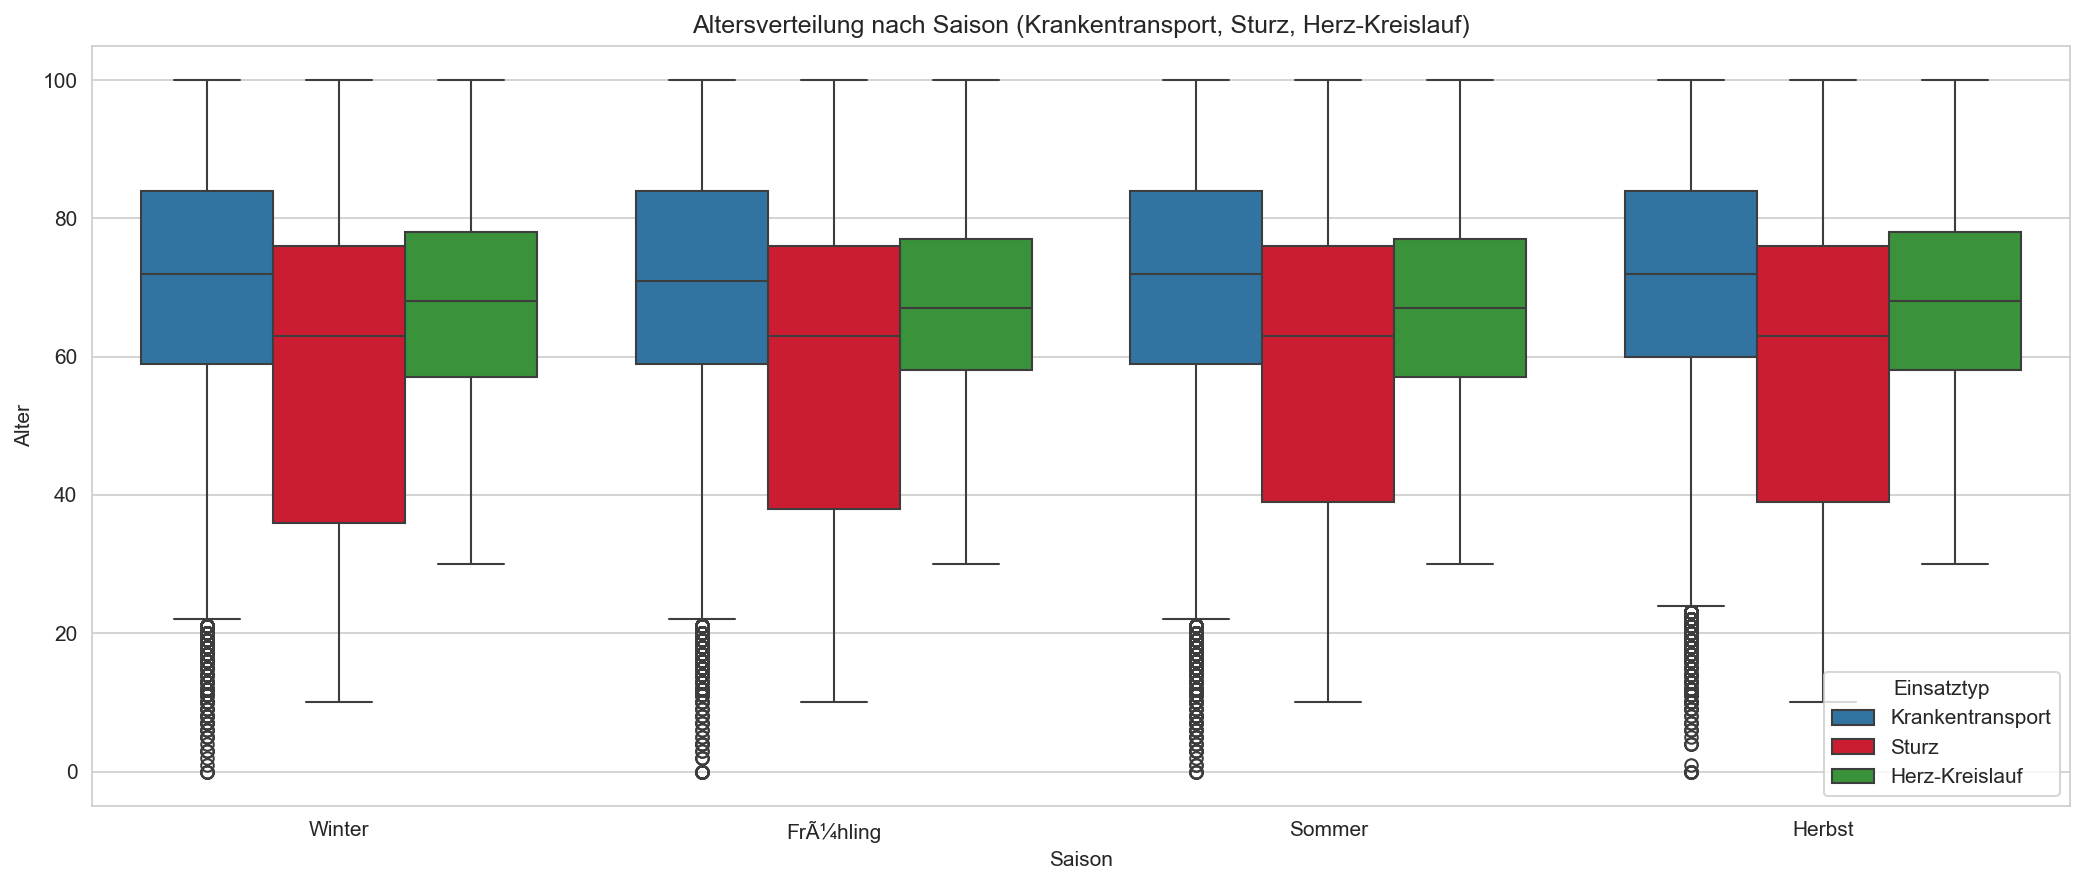

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_07.png


In [20]:
age_types = ['Krankentransport', 'Sturz', 'Herz-Kreislauf']
sub_age = df[df['type_name'].isin(age_types)].copy()

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
sns.boxplot(data=sub_age, x='season_name', y='age', hue='type_name',
            order=SEASON_ORDER, hue_order=age_types,
            palette=['#1f77b4', '#E8001C', '#2ca02c'], ax=ax)

ax.set_title('Altersverteilung nach Saison (Krankentransport, Sturz, Herz-Kreislauf)')
ax.set_xlabel('Saison')
ax.set_ylabel('Alter')
ax.legend(title='Einsatztyp')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_07.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## V8 â€“ Wochenend- vs. Werktag-Effekt pro Jahr

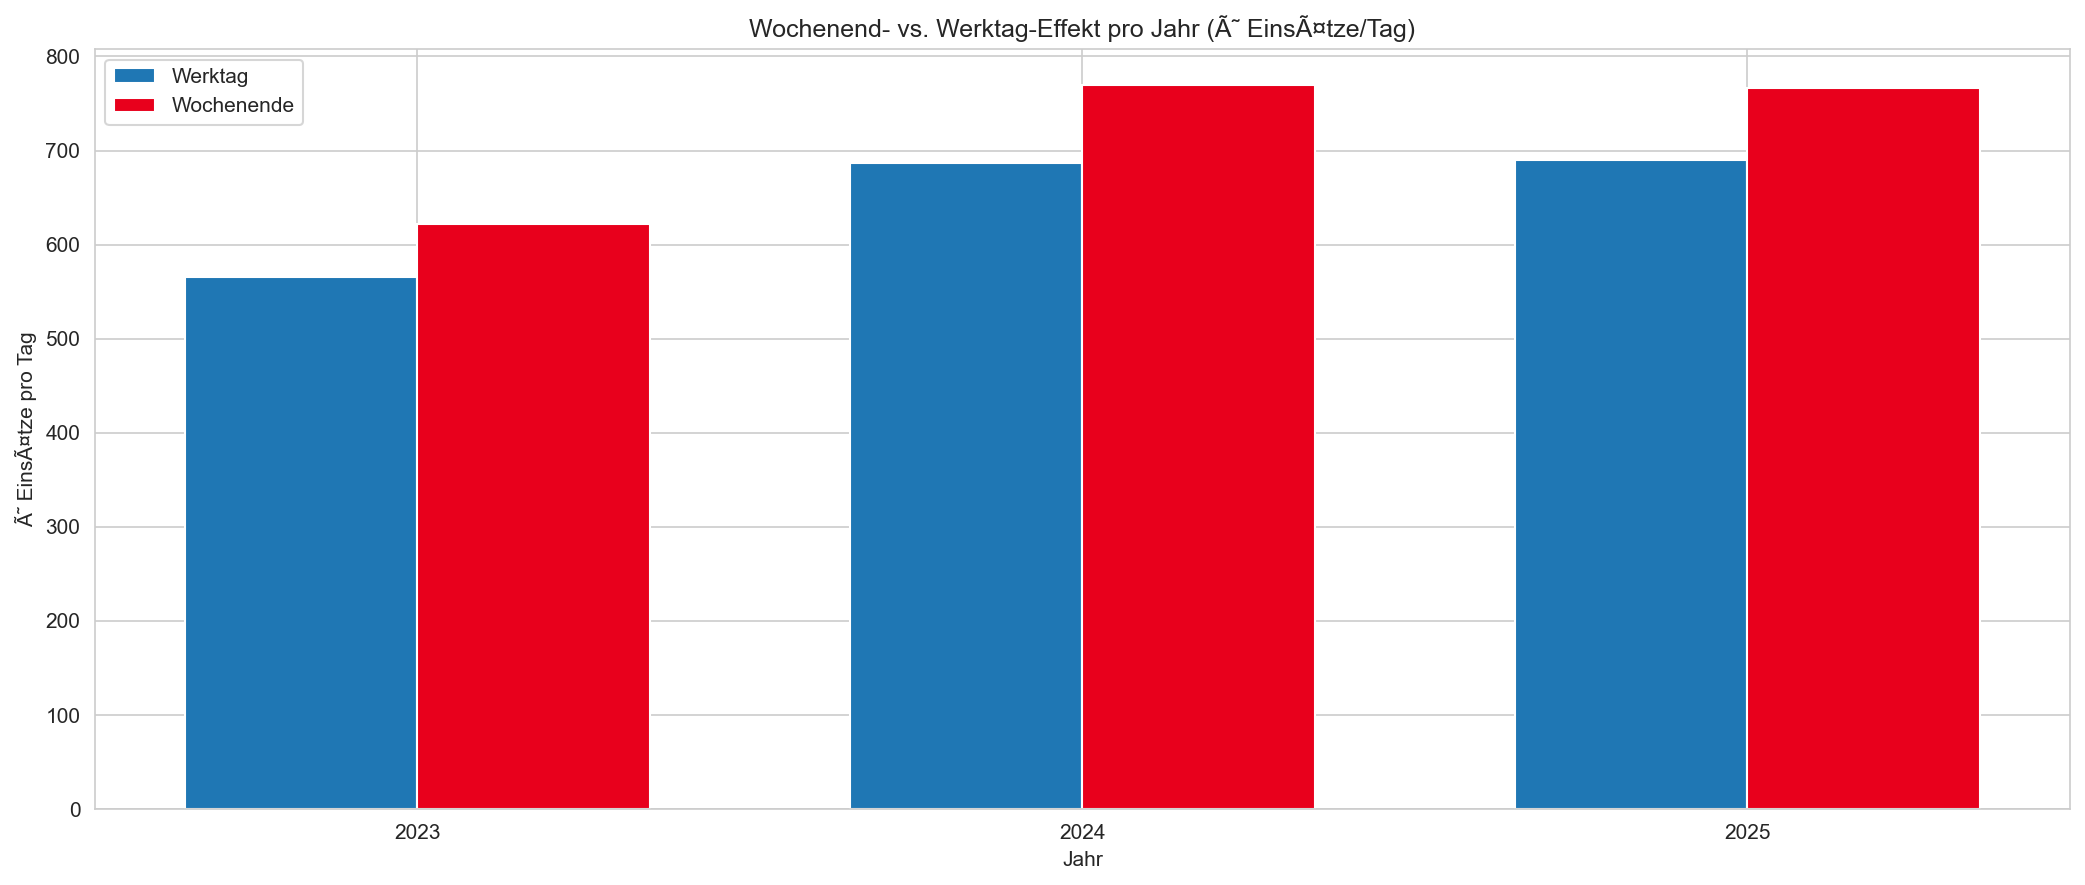

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\validierung_vergleich_08.png


In [21]:
daily_counts = df.groupby(['year', 'date']).size().reset_index(name='count')
daily_counts['is_weekend'] = pd.to_datetime(daily_counts['date']).dt.weekday >= 5

avg_per_day = daily_counts.groupby(['year', 'is_weekend'])['count'].mean().unstack('is_weekend')
avg_per_day = avg_per_day.rename(columns={False: 'Werktag', True: 'Wochenende'}).reindex(years)

x = np.arange(len(years))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
ax.bar(x - width / 2, avg_per_day['Werktag'], width, label='Werktag', color='#1f77b4')
ax.bar(x + width / 2, avg_per_day['Wochenende'], width, label='Wochenende', color='#E8001C')

ax.set_title('Wochenend- vs. Werktag-Effekt pro Jahr (Ã˜ EinsÃ¤tze/Tag)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Ã˜ EinsÃ¤tze pro Tag')
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years])
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / 'validierung_vergleich_08.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## Zusammenfassung â€“ Kennzahlen im Jahresvergleich

In [22]:
summary_rows = []
for year in years:
    ydf = df[df['year'] == year]
    y_is_kt = ydf['type_name'] == 'Krankentransport'
    summary_rows.append({
        'Jahr': year,
        'Gesamtanzahl': len(ydf),
        'Ã˜ EinsÃ¤tze/Tag': round(len(ydf) / ydf['date'].nunique(), 1),
        'Anteil Krankentransport (%)': round(y_is_kt.mean() * 100, 1),
        'Anteil NotfÃ¤lle (%)': round((~y_is_kt).mean() * 100, 1),
        'Median Alter': ydf['age'].median(),
        'Anteil weiblich (%)': round((ydf['gender'] == 'w').mean() * 100, 1),
        'HÃ¤ufigster Einsatztyp': ydf['type_name'].value_counts().idxmax(),
        'HÃ¤ufigstes Gebiet': GEBIET_NAMES.get(
            ydf.loc[ydf['gebiet_id'] != -1, 'gebiet_id'].value_counts().idxmax()
        ),
    })

summary_table = pd.DataFrame(summary_rows).set_index('Jahr').T
print('=== Kennzahlen im Jahresvergleich (2023â€“2025) ===\n')
print(summary_table.to_string())
summary_table

=== Kennzahlen im Jahresvergleich (2023â€“2025) ===

Jahr                                     2023              2024              2025
Gesamtanzahl                           212453            260025            259909
Ã˜ EinsÃ¤tze/Tag                        582.1             710.5             712.1
Anteil Krankentransport (%)              82.8              81.7              81.7
Anteil NotfÃ¤lle (%)                     17.2              18.3              18.3
Median Alter                             69.0              69.0              69.0
Anteil weiblich (%)                      51.0              50.8              50.7
HÃ¤ufigster Einsatztyp       Krankentransport  Krankentransport  Krankentransport
HÃ¤ufigstes Gebiet                       Linz              Linz              Linz


Jahr,2023,2024,2025
Gesamtanzahl,212453,260025,259909
Ã˜ EinsÃ¤tze/Tag,582.1,710.5,712.1
Anteil Krankentransport (%),82.8,81.7,81.7
Anteil NotfÃ¤lle (%),17.2,18.3,18.3
Median Alter,69.0,69.0,69.0
Anteil weiblich (%),51.0,50.8,50.7
HÃ¤ufigster Einsatztyp,Krankentransport,Krankentransport,Krankentransport
HÃ¤ufigstes Gebiet,Linz,Linz,Linz
